In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import polars as pl
from spacy.lang.es.stop_words import STOP_WORDS

from utils import (
    barh,
    boxplot,
    chat_dirs,
    columns,
    connect,
    heatmap,
    line,
    note,
    wordcloud,
)
from wasap_group_analyzer.config import load_params
from wasap_group_analyzer.text import (
    CHAT_STOP_WORDS,
    clean_content,
    emoji_name,
    extract_emojis,
    is_edited,
    load_nlp,
    message_type,
    text_for_words,
    tokenize,
)

# Tamaño de la muestra de mensajes de texto para explorar con spaCy (la muestra es
# reproducible: misma semilla, mismos mensajes).
SAMPLE_SIZE = 20_000

# EDA silver: de los mensajes anonimizados a datos tidy

**Parte 1** decide, con datos, cómo convertir `data/interim/<chat>/messages_anon.parquet`
(una fila por registro: `message_id`, `timestamp`, `sender_id`, `kind` y el `body`
enmascarado) en los conjuntos tidy de silver (`data/processed/<chat>/`). Cada decisión
ya está implementada en el paquete (`text.py`, `aliases.py`) y la usa el job de silver;
aquí se aplica a los datos para justificarla. **Partes 2 y 3** responden preguntas con
silver.

**Privacidad.** Solo se lee la versión anonimizada, y nunca se muestra un mensaje
completo: solo conteos, palabras sueltas y ejemplos inventados.

In [ ]:
dirs = chat_dirs()
con = connect()

# Funciones del paquete disponibles en SQL.
con.create_function(
    "message_type", message_type, ["VARCHAR", "VARCHAR"], "VARCHAR", null_handling="special"
)
con.create_function("is_edited", is_edited, ["VARCHAR"], "BOOLEAN", null_handling="special")
con.create_function("emojis", extract_emojis, ["VARCHAR"], "VARCHAR[]", null_handling="special")
con.create_function("emoji_name", emoji_name, ["VARCHAR"], "VARCHAR")

# Alias de cada miembro: los asigna el job de anonimización (ver sección 2).
member_aliases = con.sql("SELECT sender_id, alias FROM members").pl()
alias_by_id = dict(zip(member_aliases["sender_id"], member_aliases["alias"]))
con.create_function(
    "clean_content",
    lambda kind, body: clean_content(kind, body, alias_by_id),
    ["VARCHAR", "VARCHAR"],
    "VARCHAR",
    null_handling="special",
)
note(f"Chat activo: **{dirs['chat']}**")

Chat activo: baketon_city

## 1. Tipos de mensaje

`avisos_del_grupo` son los mensajes que WhatsApp firma con el nombre del grupo y no
con una persona (el aviso de cifrado, la llegada de Meta AI): su `sender_id` queda
vacío y no reciben alias. `con_cuerpo` son los registros que conservan texto (`text`,
`attachment` y `poll`).

In [ ]:
overview = mo.sql(
    f"""
    SELECT
        count(*) AS registros,
        count(DISTINCT sender_id) AS personas,
        count(*) FILTER (sender_id IS NULL) AS avisos_del_grupo,
        count(*) FILTER (body IS NOT NULL) AS con_cuerpo,
        min(timestamp) AS desde,
        max(timestamp) AS hasta
    FROM messages_anon
    """,
    engine=con
)

registros,personas,avisos_del_grupo,con_cuerpo,desde,hasta
259014,42,11,256528,2024-09-28 14:31:21,2026-09-18 16:45:29


`kind` junta todos los adjuntos en `attachment`; para responder "¿quién manda más
stickers?" hay que separarlos. El marcador que deja WhatsApp (`sticker omitted`,
`image omitted`...) da el tipo: `text.message_type()` lo convierte en `message_type`,
igual a `kind` salvo en los adjuntos.

In [ ]:
types = mo.sql(
    f"""
    SELECT
        message_type(kind, body) AS message_type,
        count(*) AS mensajes,
        round(100 * count(*) / sum(count(*)) OVER (), 2) AS pct,
        count(*) FILTER (kind = 'attachment' AND clean_content(kind, body) IS NOT NULL)
            AS con_pie_de_foto
    FROM messages_anon
    GROUP BY ALL
    ORDER BY mensajes DESC
    """,
    engine=con
)

message_type,mensajes,pct,con_pie_de_foto
"""text""",226829,87.57,0
"""sticker""",21159,8.17,0
"""image""",7220,2.79,3232
"""view_once""",1393,0.54,0
"""deleted""",414,0.16,0
"""audio""",409,0.16,0
"""video""",338,0.13,103
"""gif""",287,0.11,25
"""unavailable""",280,0.11,0
"""poll""",177,0.07,0


Los tipos se quedan así. Los *mensajes de texto* (para palabras por mensaje) son solo
`text`; los pies de foto y las encuestas también los escribe alguien, así que sus
palabras cuentan para "las palabras más usadas", pero no como mensajes de texto.

## 2. Alias de los miembros

Cada `sender_id` recibe el nombre de un animal de México (Ajolote, Jaguar, Quetzal,
Tlacuache...) en el orden en que escribió por primera vez. Los asigna el job de
anonimización (`interim/<chat>/members.parquet`), el único que conoce los nombres
reales: salta cualquier animal que comparta una palabra con el nombre de un miembro,
para que el alias no dé pistas. El orden no depende del hash, y una exportación más
nueva solo agrega animales al final.

## 3. Contenido legible

El `body` de interim todavía trae ruido: marcas invisibles, el sufijo
`<This message was edited>`, el marcador del adjunto y los ids de las marcas de
anonimización. `text.clean_content()` deja el texto que escribió el usuario, con los
miembros como `@[Alias]` (mención) o `[Alias]` (nombre en el texto); los corchetes
distinguen a un miembro de, por ejemplo, alguien hablando de Juárez. Para contar
palabras, `text.text_for_words()` quita además las marcas entre corchetes y las
etiquetas de las encuestas.

Con mensajes inventados:

In [ ]:
_lrm = chr(0x200E)
_someone = next(iter(alias_by_id))
_examples = [
    ("text", f"nos vemos mañana @[{_someone}] 😂 {_lrm}<This message was edited>"),
    ("attachment", f"mira esto [{_someone}] {_lrm}image omitted"),
    ("attachment", f"{_lrm}sticker omitted"),
    ("text", "checa [url:youtube.com] y me dices, [nombre] ya lo vio"),
    ("poll", "POLL:\n¿Dónde comemos?\nOPTION: Tacos (3 votes)\nOPTION: Pizza (1 vote)"),
]
_rows = []
for _kind, _body in _examples:
    _content = clean_content(_kind, _body, alias_by_id)
    _rows.append(
        {
            "kind": _kind,
            "body en interim": _body.replace(_lrm, "‹U+200E›"),
            "is_edited": is_edited(_body),
            "content": _content,
            "texto para palabras": " ".join(text_for_words(_content).split()),
        }
    )
pl.DataFrame(_rows)

kind,body en interim,is_edited,content,texto para palabras
"""text""","""nos vemos mañana @[5a34656d26] 😂 ‹U+200E›<This message was edited>""",true,"""nos vemos mañana @[Ajolote] 😂""","""nos vemos mañana 😂"""
"""attachment""","""mira esto [5a34656d26] ‹U+200E›image omitted""",false,"""mira esto [Ajolote]""","""mira esto"""
"""attachment""","""‹U+200E›sticker omitted""",false,null,""""""
"""text""","""checa [url:youtube.com] y me dices, [nombre] ya lo vio""",false,"""checa [url:youtube.com] y me dices, [nombre] ya lo vio""","""checa y me dices, ya lo vio"""
"""poll""","""POLL: ¿Dónde comemos? OPTION: Tacos (3 votes) OPTION: Pizza (1 vote)""",false,"""POLL: ¿Dónde comemos? OPTION: Tacos (3 votes) OPTION: Pizza (1 vote)""","""¿Dónde comemos? Tacos Pizza"""


In [ ]:
content_marks = mo.sql(
    f"""
    WITH c AS (
        SELECT kind, body, clean_content(kind, body) AS content
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    SELECT
        count(*) FILTER (content IS NOT NULL) AS con_contenido,
        count(*) FILTER (is_edited(body)) AS editados,
        count(*) FILTER (contains(content, '@[')) AS con_mencion,
        count(*) FILTER (
            len(list_filter(
                regexp_extract_all(content, '(^|[^@])[[]([^]]+)[]]', 2),
                x -> x NOT IN ('nombre', 'numero', 'correo') AND NOT starts_with(x, 'url:')
            )) > 0
        ) AS con_nombre_de_miembro,
        count(*) FILTER (contains(content, '[nombre]')) AS con_nombre_ambiguo_o_apodo,
        count(*) FILTER (contains(content, '[url:')) AS con_url,
        count(*) FILTER (contains(content, '[numero]')) AS con_numero,
        count(*) FILTER (contains(content, '[correo]')) AS con_correo
    FROM c
    """,
    engine=con
)

con_contenido,editados,con_mencion,con_nombre_de_miembro,con_nombre_ambiguo_o_apodo,con_url,con_numero,con_correo
230411,1938,7753,12393,8349,739,433,36


## 4. Emojis

`text.extract_emojis()` usa la librería `emoji`, que reconoce secuencias completas: un
emoji con tono de piel (👍🏽) o una familia unida con ZWJ cuenta como uno solo. Los
emoticonos de texto como `:(` o `xD` no son emojis. Cada emoji será una fila de la
tabla `emojis` de silver, con su nombre en español.

In [ ]:
emoji_summary = mo.sql(
    f"""
    WITH e AS (
        SELECT message_id, unnest(emojis(clean_content(kind, body))) AS emoji
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    SELECT
        count(DISTINCT message_id) AS mensajes_con_emoji,
        count(*) AS emojis,
        count(DISTINCT emoji) AS emojis_distintos,
        count(*) FILTER (contains(emoji, chr(8205))) AS secuencias_zwj,
        count(*) FILTER (
            regexp_matches(emoji, '[' || chr(127995) || '-' || chr(127999) || ']')
        ) AS con_tono_de_piel
    FROM e
    """,
    engine=con
)

mensajes_con_emoji,emojis,emojis_distintos,secuencias_zwj,con_tono_de_piel
5664,10132,739,248,195


In [ ]:
top_emojis = mo.sql(
    f"""
    SELECT emoji, emoji_name(emoji) AS nombre, count(*) AS veces
    FROM (
        SELECT unnest(emojis(clean_content(kind, body))) AS emoji
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    GROUP BY emoji
    ORDER BY veces DESC
    LIMIT 10
    """,
    engine=con
)

emoji,nombre,veces
"""😭""","""cara llorando fuerte""",512
"""🔥""","""fuego""",470
"""😍""","""cara sonriendo con ojos de corazón""",413
"""🗣️""","""cabeza parlante""",400
"""🥶""","""cara con frío""",389
"""✅""","""botón de marca de verificación""",294
"""🥵""","""cara con calor""",287
"""😂""","""cara llorando de risa""",284
"""👀""","""ojos""",245
"""🥰""","""cara sonriendo con corazones""",205


## 5. Qué cuenta como palabra

Para palabras, adjetivos y stop words se usa spaCy (`es_core_news_sm`), que separa
tokens, etiqueta su categoría gramatical (POS) y da su lema. Para explorar basta una
muestra reproducible de mensajes de texto; el job de silver procesa todos.

In [ ]:
sample = con.sql(
    f"""
    SELECT message_id, clean_content(kind, body) AS content
    FROM (SELECT * FROM messages_anon WHERE kind = 'text')
    USING SAMPLE reservoir({SAMPLE_SIZE} ROWS) REPEATABLE (42)
    """
).pl()
_words_text = [text_for_words(content) for content in sample["content"]]
sample = sample.with_columns(
    pl.Series("split_by_spaces", [len(text.split()) for text in _words_text])
)
nlp = load_nlp(load_params()["nlp"]["model"])
_rows = []
for _message_id, _tokens in zip(sample["message_id"], tokenize(nlp, _words_text)):
    _rows += [{"message_id": _message_id, **_token} for _token in _tokens]
sample_tokens = pl.DataFrame(_rows).with_columns(
    pl.col("token").is_in(list(STOP_WORDS)).alias("is_spacy_stop")
)
con.register("sample", sample)
con.register("sample_tokens", sample_tokens)
note(f"Muestra: **{len(sample):,}** mensajes de texto, **{len(sample_tokens):,}** tokens.")

Muestra: 20,000 mensajes de texto, 104,727 tokens.

Un mensaje inventado, token por token. Una **palabra** es un token alfabético
(`is_alpha`: solo letras, con o sin acento); números, signos, emojis y emoticonos son
tokens pero no palabras:

In [ ]:
_example = "jajaja no manches 😂 mañana a las 5pm vamos al cine, está buenísima la peli xD"
pl.DataFrame(next(tokenize(nlp, [_example]))).drop("token_idx")

token,lemma,pos,is_alpha,is_stop,is_laugh
"""jajaja""","""jajaja""","""NOUN""",true,true,true
"""no""","""no""","""ADV""",true,true,false
"""manches""","""manch""","""NOUN""",true,false,false
"""😂""","""😂""","""ADP""",false,false,false
"""mañana""","""mañana""","""ADV""",true,false,false
"""a""","""a""","""ADP""",true,true,false
"""las""","""el""","""DET""",true,true,false
"""5""","""5""","""NUM""",false,false,false
"""pm""","""pm""","""ADP""",true,false,false
"""vamos""","""ir""","""VERB""",true,true,false


In [ ]:
definitions = mo.sql(
    f"""
    WITH per_message AS (
        SELECT
            s.message_id,
            s.split_by_spaces AS por_espacios,
            count(t.token) FILTER (t.is_alpha) AS palabras
        FROM sample AS s
        LEFT JOIN sample_tokens AS t USING (message_id)
        GROUP BY ALL
    )
    SELECT
        round(avg(por_espacios), 2) AS promedio_separando_por_espacios,
        round(avg(palabras), 2) AS promedio_palabras_spacy,
        median(palabras) AS mediana_palabras_spacy,
        count(*) FILTER (palabras = 0) AS mensajes_sin_palabras
    FROM per_message
    """,
    engine=con
)

promedio_separando_por_espacios,promedio_palabras_spacy,mediana_palabras_spacy,mensajes_sin_palabras
4.98,4.83,4.0,720


Separar por espacios cuenta de más ("5pm", "😂" y "xD" no son palabras). Los mensajes
sin palabras son solo emojis, números o signos.

## 6. Risas y palabras vacías

Las risas son las "palabras" más escritas después de las vacías, con muchas variantes.
`text.LAUGH` reconoce al menos dos sílabas iguales (`jaja`, `jejeje`, `haha`),
variantes con s (`jsjsjs`), `xd` y `lol`, sin atrapar palabras reales como "he", "ha". Cada token lleva `is_laugh` en silver y cuenta como palabra vacía.

In [ ]:
laughs = mo.sql(
    f"""
    SELECT token AS risa, count(*) AS veces
    FROM sample_tokens
    WHERE is_laugh
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 10
    """,
    engine=con
)

risa,veces
"""jaja""",87
"""jajaja""",80
"""xd""",72
"""jajajaja""",45
"""lol""",38
"""jajaj""",36
"""jajajajaja""",25
"""jajajaj""",22
"""jajajajajaja""",14
"""jeje""",13


Con solo la lista de spaCy (`STOP_WORDS`, ~500 palabras del español escrito), las
palabras "con contenido" más frecuentes son en realidad muletillas y abreviaturas del
chat:

In [ ]:
spacy_only = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM sample_tokens
    WHERE is_alpha AND NOT is_spacy_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con
)

palabra,veces
"""we""",916
"""q""",909
"""pa""",304
"""verga""",195
"""pq""",189
"""casa""",156
"""pedo""",153
"""w""",152
"""vas""",151
"""d""",149


In [ ]:
note(
    "Por eso `text.CHAT_STOP_WORDS` agrega abreviaturas de palabras vacías, muletillas "
    "y vocativos del chat, y `text.is_stop_word()` considera vacía también cualquier "
    "palabra de una sola letra y cualquier risa. La jerga con significado (*neta*, "
    "*chamba*, *pedo*) sigue siendo contenido. La lista:\n\n"
    + ", ".join(f"`{word}`" for word in sorted(CHAT_STOP_WORDS))
)

Por eso text.CHAT_STOP_WORDS agrega abreviaturas de palabras vacías, muletillas y vocativos del chat, y text.is_stop_word() considera vacía también cualquier palabra de una sola letra y cualquier risa. La jerga con significado ( neta , chamba , pedo ) sigue siendo contenido. La lista: 
 ah , aja , ajá , ay , bro , eh , guey , güey , k , ke , mm , mmm , mmmm , nel , nomas , nomás , nop , ntp , oh , ok , okay , oki , osea , pa , pal , pk , porq , pos , pq , ps , q , qe , simon , sip , smn , tambn , tb , tmb , tmbn , uh , va , we , wey , xq

In [ ]:
content_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM sample_tokens
    WHERE is_alpha AND NOT is_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con
)

palabra,veces
"""verga""",195
"""casa""",156
"""pedo""",153
"""vas""",151
"""amigo""",125
"""fc""",109
"""qp""",102
"""gracias""",97
"""tienes""",95
"""neta""",91


## 7. Adjetivos

spaCy etiqueta los adjetivos como `ADJ`. Se cuentan por lema, para que *buenas* y
*bueno* sean el mismo adjetivo. Aquí **no** se filtran las palabras vacías: la lista
de spaCy incluye justo los adjetivos más comunes (*bueno*, *mejor*, *nuevo*,
*grande*), y quitarlos dejaría fuera la respuesta. Solo se excluyen las risas y las
letras sueltas.

In [ ]:
adjectives = mo.sql(
    f"""
    SELECT lemma AS adjetivo, count(*) AS veces
    FROM sample_tokens
    WHERE pos = 'ADJ' AND is_alpha AND NOT is_laugh AND length(token) > 1
    GROUP BY lemma
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con
)

adjetivo,veces
"""bueno""",219
"""mejor""",114
"""vergo""",65
"""primero""",63
"""nuevo""",62
"""solo""",60
"""puro""",48
"""amigo""",41
"""feliz""",40
"""viejo""",39


La mayoría son adjetivos reales, pero el modelo pequeño de spaCy se entrenó con
noticias, no con chats: con la jerga y los mensajes sin puntuación toma algún
sustantivo (*amigo*), verbo (*anda*) o abreviatura por adjetivo, y a veces no lematiza
el femenino. Se acepta esa limitación y se comenta al responder la pregunta, en lugar
de corregir la lista a mano.

## 8. Especificación de silver

El job de silver (`make process`) escribe tres conjuntos tidy en
`data/processed/<chat>/`, cada uno con su diccionario de datos en `references/`
(`make dictionary` junta las descripciones con el perfil que calcula DuckDB).

**`messages.parquet`**: una fila por mensaje.

| Columna | Qué es |
|---|---|
| `message_id` | orden del registro en el archivo exportado |
| `timestamp` | fecha y hora local, sin zona |
| `sender` | alias del remitente (un animal); vacío en avisos del grupo |
| `message_type` | tipo de mensaje (sección 1) |
| `content` | texto legible (sección 3); vacío si no hay texto |
| `is_edited` | si el mensaje fue editado |
| `n_words` | palabras (tokens alfabéticos) del contenido |
| `n_emojis` | emojis del contenido |
| `n_mentions` | menciones a miembros |
| `has_url` | si trae un enlace |

**`tokens.parquet`**: una fila por token del contenido (texto, pies de foto y
encuestas): `message_id`, `token_idx`, `token`, `lemma`, `pos`, `is_alpha`,
`is_stop`, `is_laugh`.

**`emojis.parquet`**: una fila por emoji: `message_id`, `emoji_idx`, `emoji`,
`emoji_name`.

El remitente, la fecha y el tipo de un token o de un emoji se obtienen uniendo con
`messages` por `message_id`: cada dato vive en una sola tabla.

---

# Parte 2: las preguntas

Todo lo que sigue sale de los tres conjuntos de silver (`make process`), con SQL sobre
`messages`, `tokens` y `emojis`. "Usuario" es el alias de cada miembro.

In [ ]:
mo.stop(
    not (dirs["processed"] / "messages.parquet").exists(),
    note("Faltan los datos de silver: corre `make process` y vuelve a ejecutar."),
)

## 9. ¿Quién manda más mensajes?

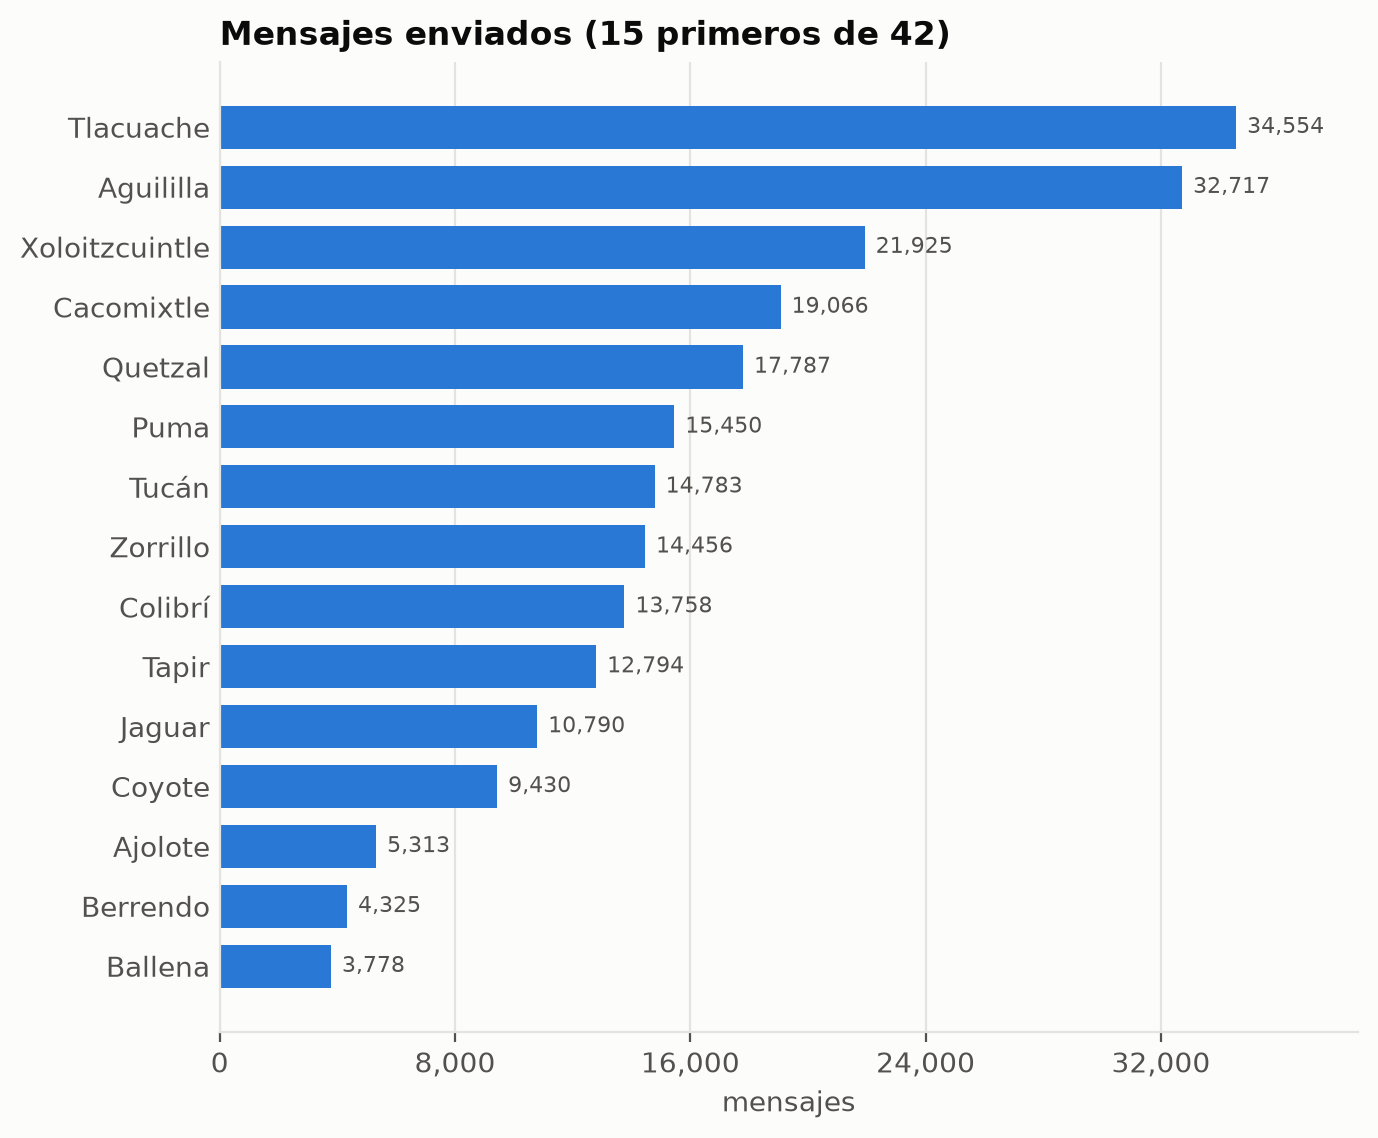

In [ ]:
by_sender = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        count(*) AS mensajes,
        round(100 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM messages
    WHERE sender IS NOT NULL
    GROUP BY sender
    ORDER BY mensajes DESC
    """,
    engine=con,
    output=False,
)
barh(
    by_sender["usuario"][:15],
    by_sender["mensajes"][:15],
    "Mensajes enviados (15 primeros de 42)",
    "mensajes",
)

In [ ]:
_top = by_sender.row(0, named=True)
_half = (by_sender["mensajes"].cum_sum() / by_sender["mensajes"].sum() <= 0.5).sum() + 1
note(
    f"**{_top['usuario']}** manda más mensajes que nadie: **{_top['mensajes']:,}** "
    f"({_top['pct']}% de todos los mensajes del grupo), seguido de "
    f"{by_sender['usuario'][1]} con {by_sender['mensajes'][1]:,}. La conversación está "
    f"concentrada: entre **{_half}** de las {len(by_sender)} personas escriben la mitad "
    f"de los mensajes."
)

Tlacuache manda más mensajes que nadie: 34,554 (13.3% de todos los mensajes del grupo), seguido de Aguililla con 32,717. La conversación está concentrada: entre 6 de las 42 personas escriben la mitad de los mensajes.

## 10. ¿Cuántas palabras por mensaje de texto escribe cada quien?

Solo mensajes de texto (`message_type = 'text'`), porque un sticker o una foto sin pie
no tienen palabras y bajarían el promedio de quien manda muchos.

In [ ]:
words_per_sender = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        count(*) AS mensajes_de_texto,
        round(avg(n_words), 2) AS palabras_por_mensaje,
        median(n_words) AS mediana,
        max(n_words) AS mensaje_mas_largo
    FROM messages
    WHERE sender IS NOT NULL AND message_type = 'text'
    GROUP BY sender
    HAVING count(*) >= 100
    ORDER BY palabras_por_mensaje DESC
    """,
    engine=con
)

usuario,mensajes_de_texto,palabras_por_mensaje,mediana,mensaje_mas_largo
"""Correcaminos""",392,58.65,23.0,950
"""Garza""",354,7.92,6.0,271
"""Cocodrilo""",1845,6.71,5.0,591
"""Vaquita""",187,6.52,6.0,21
"""Jabalí""",208,6.31,4.0,47
"""Zopilote""",1791,5.84,4.0,137
"""Ballena""",3366,5.56,5.0,139
"""Mapache""",3174,5.55,4.0,557
"""Tapir""",10700,5.29,4.0,355
"""Ajolote""",4592,5.18,4.0,97


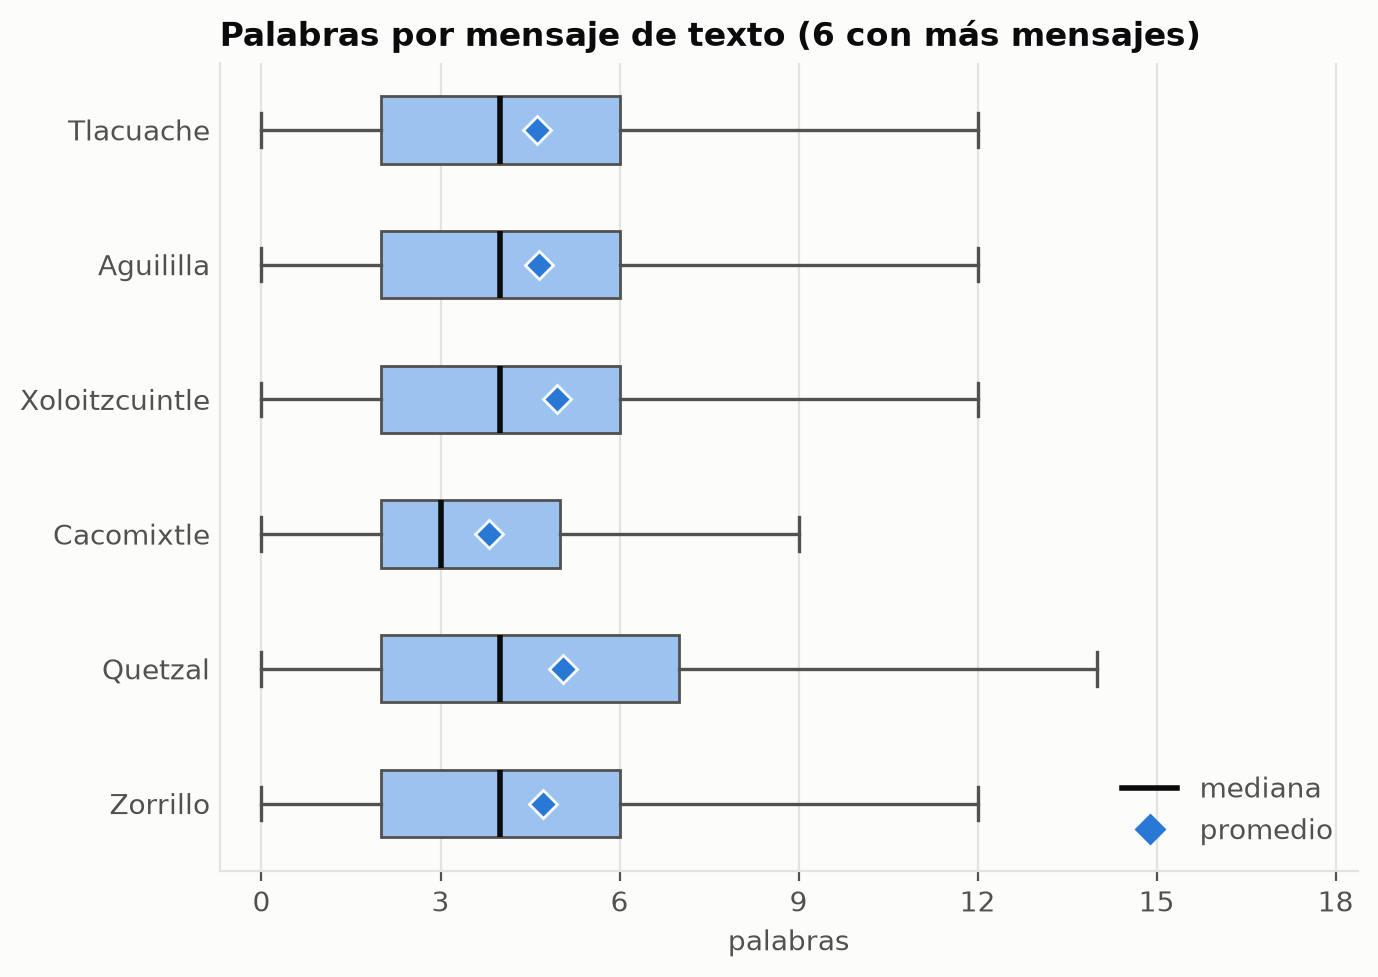

In [ ]:
_top = words_per_sender.sort("mensajes_de_texto", descending=True).head(6)["usuario"]
top_words_per_message = mo.sql(
    f"""
    SELECT sender AS usuario, n_words AS palabras
    FROM messages
    WHERE message_type = 'text' AND sender IN (
        SELECT sender
        FROM messages
        WHERE sender IS NOT NULL AND message_type = 'text'
        GROUP BY sender
        ORDER BY count(*) DESC
        LIMIT 6
    )
    """,
    engine=con,
    output=False,
)
boxplot(
    {
        user: top_words_per_message.filter(pl.col("usuario") == user)["palabras"]
        for user in _top
    },
    "Palabras por mensaje de texto (6 con más mensajes)",
    "palabras",
)

In [ ]:
_most = words_per_sender.row(0, named=True)
_second = words_per_sender.row(1, named=True)
_least = words_per_sender.row(-1, named=True)
_skewed = (words_per_sender["mediana"] < words_per_sender["palabras_por_mensaje"]).sum()
note(
    "La gráfica compara a las seis personas que más mensajes de texto mandan: la caja "
    "cubre la mitad central de sus mensajes, la línea es la mediana y el rombo el "
    "promedio; los mensajes atípicos, muy largos, no se dibujan.\n\n"
    f"En la tabla, el promedio va de **{_most['palabras_por_mensaje']}** palabras por mensaje "
    f"({_most['usuario']}) a **{_least['palabras_por_mensaje']}** ({_least['usuario']}), "
    f"una diferencia de {_most['palabras_por_mensaje'] / _least['palabras_por_mensaje']:.0f} "
    f"veces. {_most['usuario']} es un caso aparte: le sigue {_second['usuario']} con "
    f"{_second['palabras_por_mensaje']}, así que el resto del grupo se mueve en un rango "
    "estrecho de mensajes cortos.\n\n"
    f"En **{_skewed} de {len(words_per_sender)}** usuarios la mediana es menor que el "
    "promedio: casi todos escriben mensajes de unas pocas palabras y, de vez en cuando, "
    "uno largo que jala el promedio hacia arriba. Se excluye a quienes escribieron "
    "menos de 100 mensajes de texto, donde el promedio es puro ruido."
)

La gráfica compara a las seis personas que más mensajes de texto mandan: la caja cubre la mitad central de sus mensajes, la línea es la mediana y el rombo el promedio; los mensajes atípicos, muy largos, no se dibujan. 
 En la tabla, el promedio va de 58.65 palabras por mensaje (Correcaminos) a 3.07 (Manatí), una diferencia de 19 veces. Correcaminos es un caso aparte: le sigue Garza con 7.92, así que el resto del grupo se mueve en un rango estrecho de mensajes cortos. 
 En 33 de 33 usuarios la mediana es menor que el promedio: casi todos escriben mensajes de unas pocas palabras y, de vez en cuando, uno largo que jala el promedio hacia arriba. Se excluye a quienes escribieron menos de 100 mensajes de texto, donde el promedio es puro ruido.

## 11. ¿Quién manda más palabras, más emojis y más stickers?

In [ ]:
totals = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        sum(n_words) AS palabras,
        sum(n_emojis) AS emojis,
        count(*) FILTER (message_type = 'sticker') AS stickers,
        count(*) AS mensajes
    FROM messages
    WHERE sender IS NOT NULL
    GROUP BY sender
    ORDER BY palabras DESC
    LIMIT 10
    """,
    engine=con
)

usuario,palabras,emojis,stickers,mensajes
"""Tlacuache""",147589,673,1881,34554
"""Aguililla""",124621,664,5428,32717
"""Xoloitzcuintle""",97126,1110,1869,21925
"""Quetzal""",77687,349,1877,17787
"""Cacomixtle""",70949,587,181,19066
"""Zorrillo""",66778,300,204,14456
"""Colibrí""",65181,2375,219,13758
"""Puma""",64452,484,1654,15450
"""Tapir""",58057,439,1247,12794
"""Jaguar""",44146,293,1336,10790


Las mismas diez personas, en el mismo orden (por palabras), en cada medida:

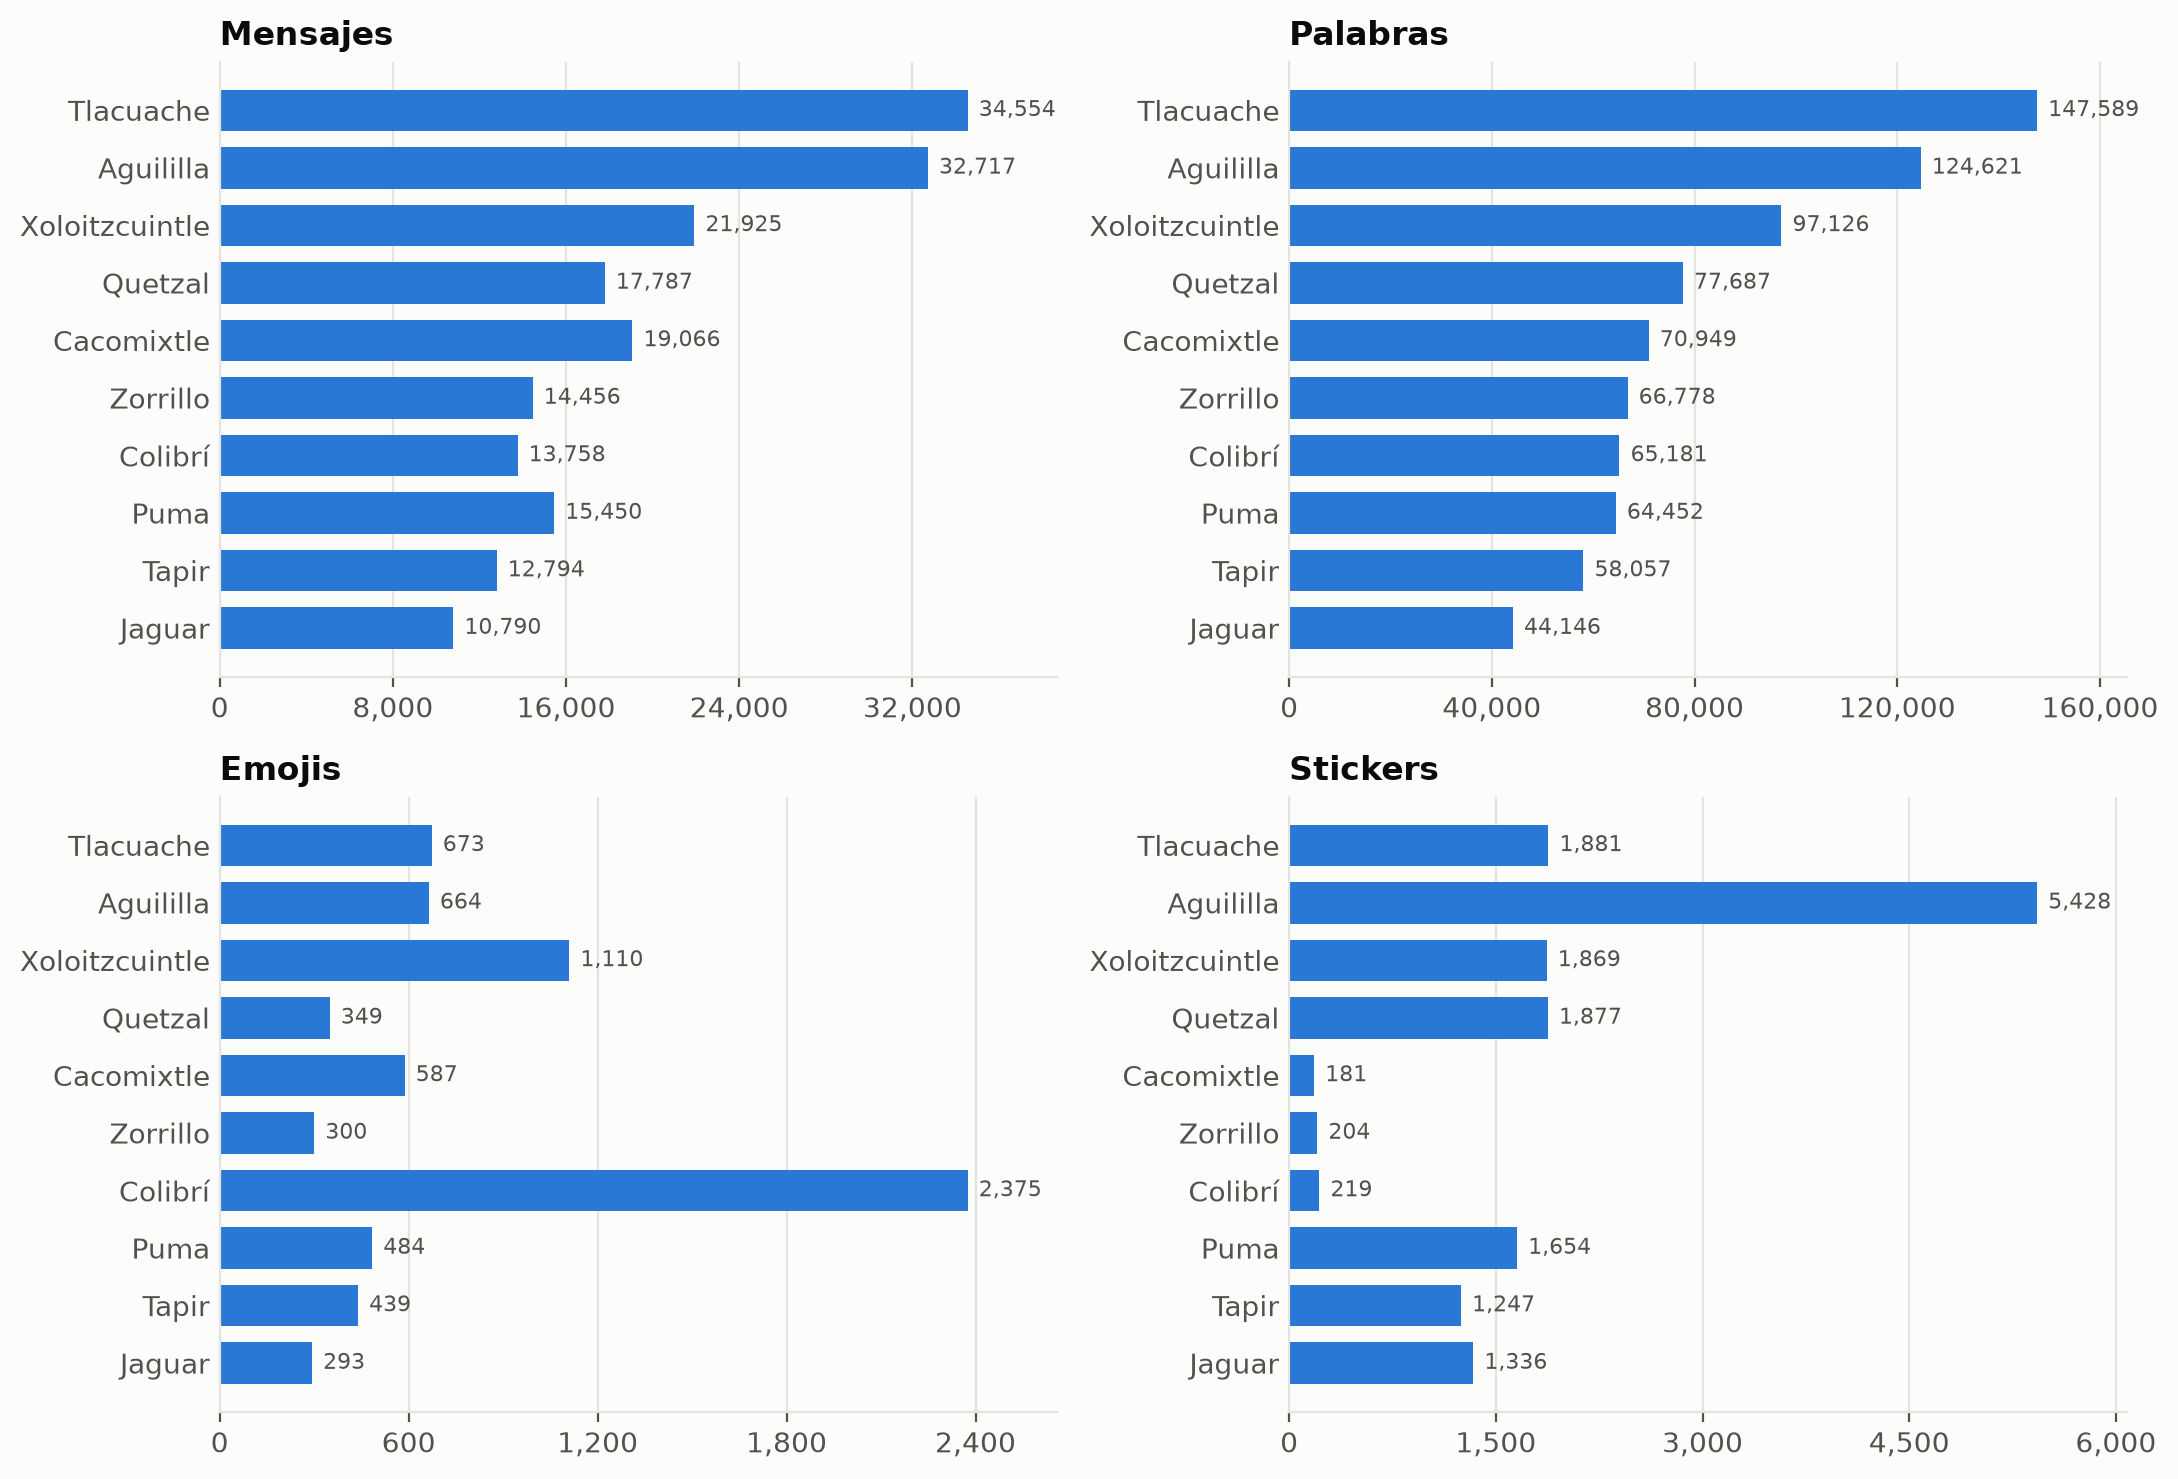

In [ ]:
_fig, _axes = plt.subplots(2, 2, figsize=(11, 7.5))
for _ax, (_column, _title) in zip(
    _axes.flat,
    [
        ("mensajes", "Mensajes"),
        ("palabras", "Palabras"),
        ("emojis", "Emojis"),
        ("stickers", "Stickers"),
    ],
):
    barh(totals["usuario"], totals[_column], _title, ax=_ax)
_fig

## 12. ¿Cuándo se escribe? Día de la semana y hora

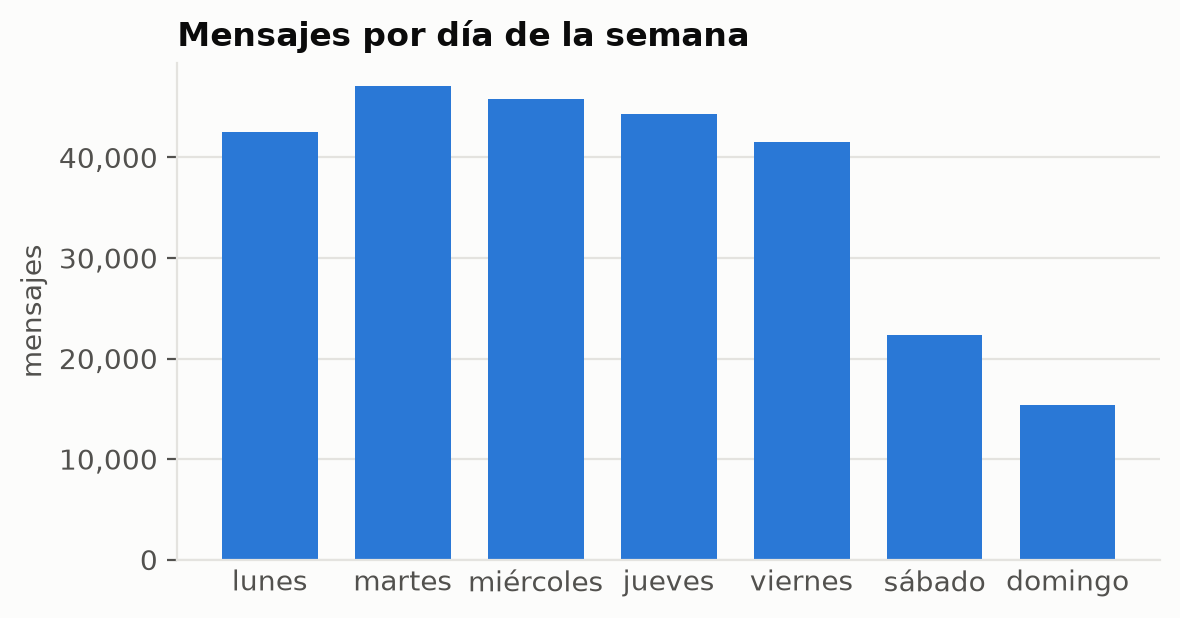

In [ ]:
by_weekday = mo.sql(
    f"""
    SELECT
        ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo'][isodow(timestamp)] AS dia,
        isodow(timestamp) AS orden,
        count(*) AS mensajes,
        round(count(*) / count(DISTINCT timestamp::DATE), 0) AS por_dia
    FROM messages
    GROUP BY ALL
    ORDER BY orden
    """,
    engine=con,
    output=False,
)
columns(by_weekday["dia"], by_weekday["mensajes"], "Mensajes por día de la semana", "mensajes")

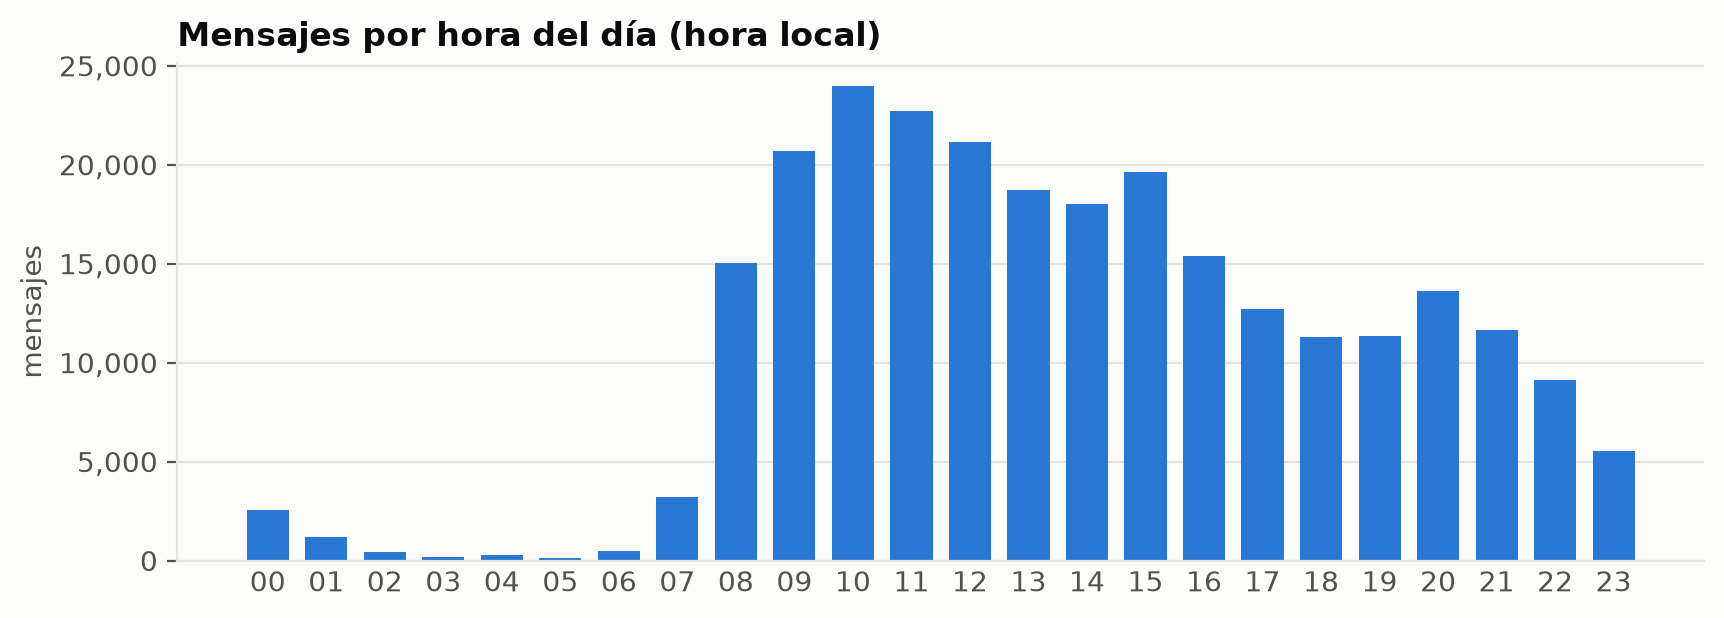

In [ ]:
by_hour = mo.sql(
    f"""
    SELECT hour(timestamp) AS hora, count(*) AS mensajes
    FROM messages
    GROUP BY hora
    ORDER BY hora
    """,
    engine=con,
    output=False,
)
columns(
    [f"{hour:02d}" for hour in by_hour["hora"]],
    by_hour["mensajes"],
    "Mensajes por hora del día (hora local)",
    "mensajes",
)

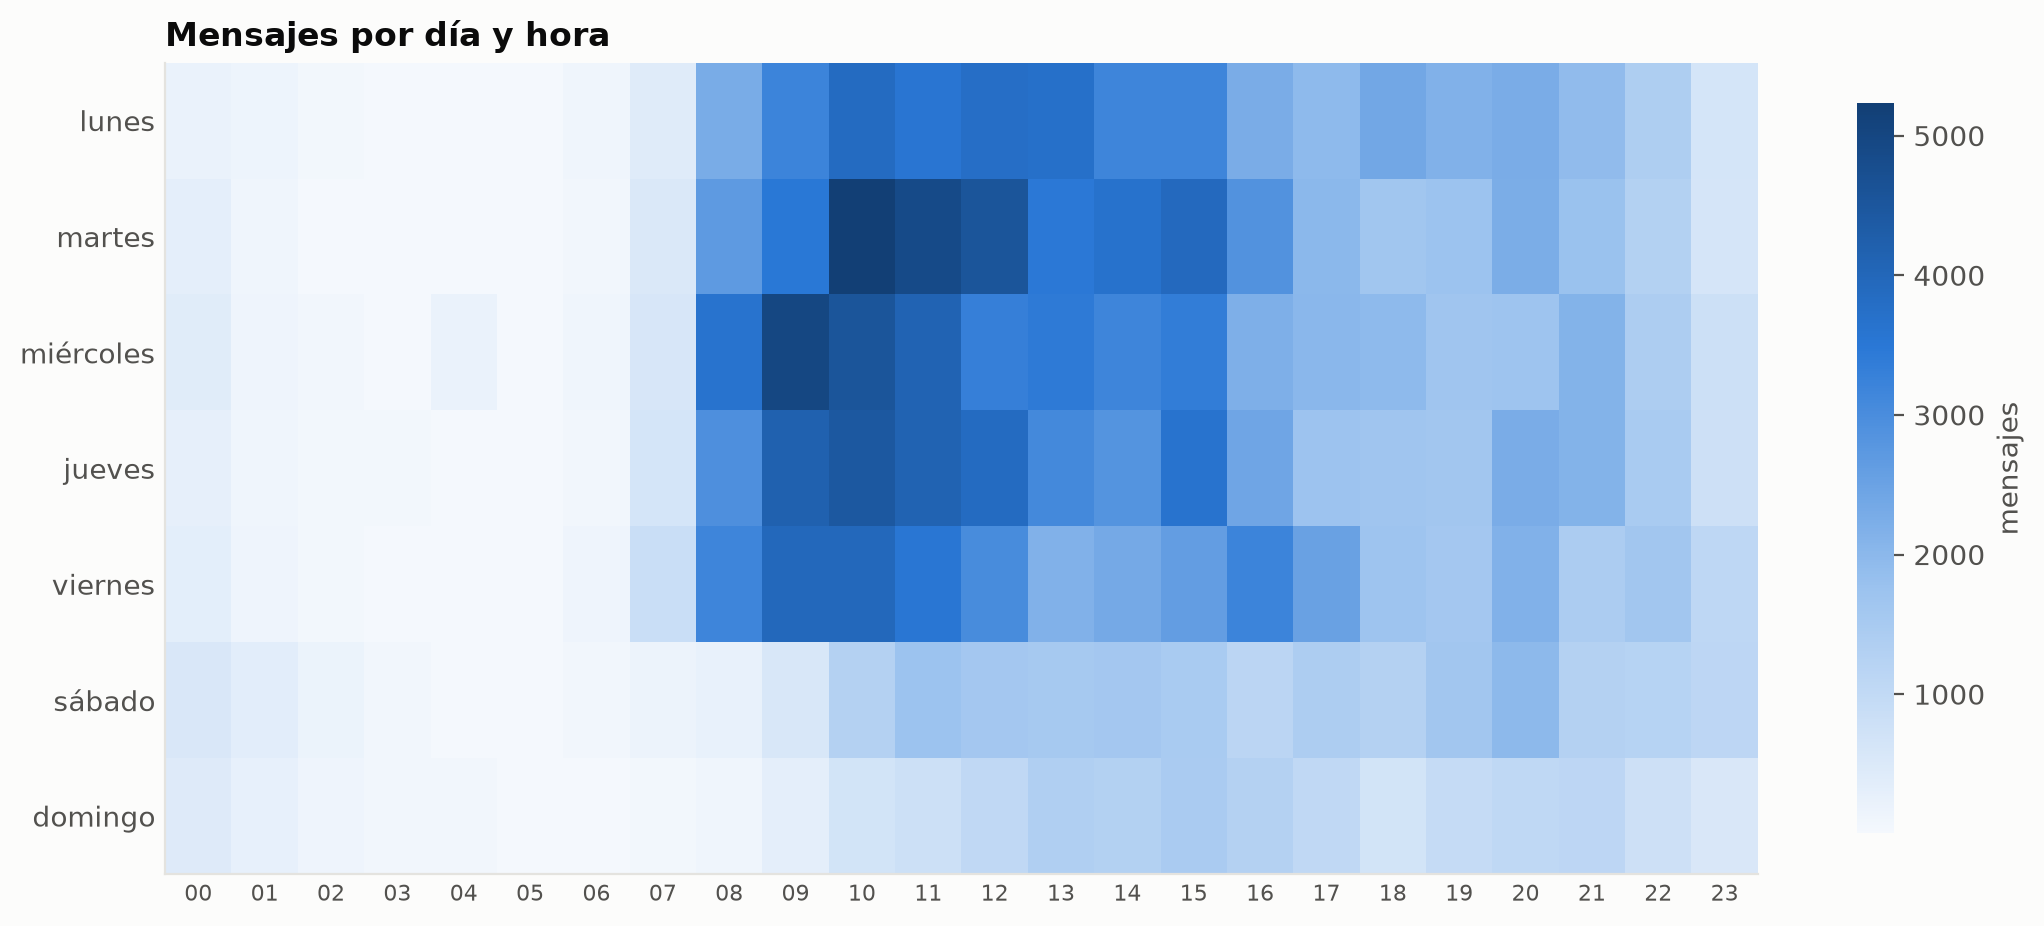

In [ ]:
weekday_hour = mo.sql(
    f"""
    SELECT isodow(timestamp) AS dia, hour(timestamp) AS hora, count(*) AS mensajes
    FROM messages
    GROUP BY ALL
    ORDER BY dia, hora
    """,
    engine=con,
    output=False,
)
_counts = {(row["dia"], row["hora"]): row["mensajes"] for row in weekday_hour.iter_rows(named=True)}
_days = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
heatmap(
    [[_counts.get((day, hour), 0) for hour in range(24)] for day in range(1, 8)],
    _days,
    [f"{hour:02d}" for hour in range(24)],
    "Mensajes por día y hora",
    "mensajes",
)

In [ ]:
_busiest = by_weekday.sort("mensajes", descending=True).row(0, named=True)
_quietest = by_weekday.sort("mensajes").row(0, named=True)
_peak = by_hour.sort("mensajes", descending=True).row(0, named=True)
_night = by_hour.filter(by_hour["hora"].is_between(4, 7))["mensajes"].sum()
note(
    f"El día más activo es el **{_busiest['dia']}** "
    f"({_busiest['mensajes']:,} mensajes) y el más callado el **{_quietest['dia']}** "
    f"({_quietest['mensajes']:,}), "
    f"{_busiest['mensajes'] / _quietest['mensajes']:.1f} veces menos. Los cinco días "
    "entre semana se parecen entre sí y el fin de semana cae"
    "o se desconecta.\n\n"
    f"El pico es a las **{_peak['hora']}:00** "
    f"({_peak['mensajes']:,} mensajes), dentro del bloque de media mañana y mediodía, y "
    f"de las 4 a las 7 de la mañana el grupo casi duerme ({_night:,} mensajes en total "
    "entre las cuatro horas). El mapa de calor muestra que ese ritmo diario se repite "
    "igual de lunes a viernes, y que las madrugadas con actividad caen sobre todo en "
    "fin de semana."
)

El día más activo es el martes (47,078 mensajes) y el más callado el domingo (15,333), 3.1 veces menos. Los cinco días entre semana se parecen entre sí y el fin de semana caeo se desconecta. 
 El pico es a las 10:00 (23,958 mensajes), dentro del bloque de media mañana y mediodía, y de las 4 a las 7 de la mañana el grupo casi duerme (4,090 mensajes en total entre las cuatro horas). El mapa de calor muestra que ese ritmo diario se repite igual de lunes a viernes, y que las madrugadas con actividad caen sobre todo en fin de semana.

## 13. ¿Qué palabras se usan más?

Primero todas las palabras, incluidas las vacías, para ver por qué hay que filtrarlas;
después solo las que tienen contenido: las 20 más usadas y, para ver más allá, una nube
con las 80 más usadas.

In [ ]:
all_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM tokens
    WHERE is_alpha
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 10
    """,
    engine=con
)

palabra,veces
"""de""",33263
"""que""",31850
"""el""",30562
"""a""",26822
"""no""",26302
"""la""",26220
"""y""",20635
"""en""",18718
"""es""",15403
"""me""",12750


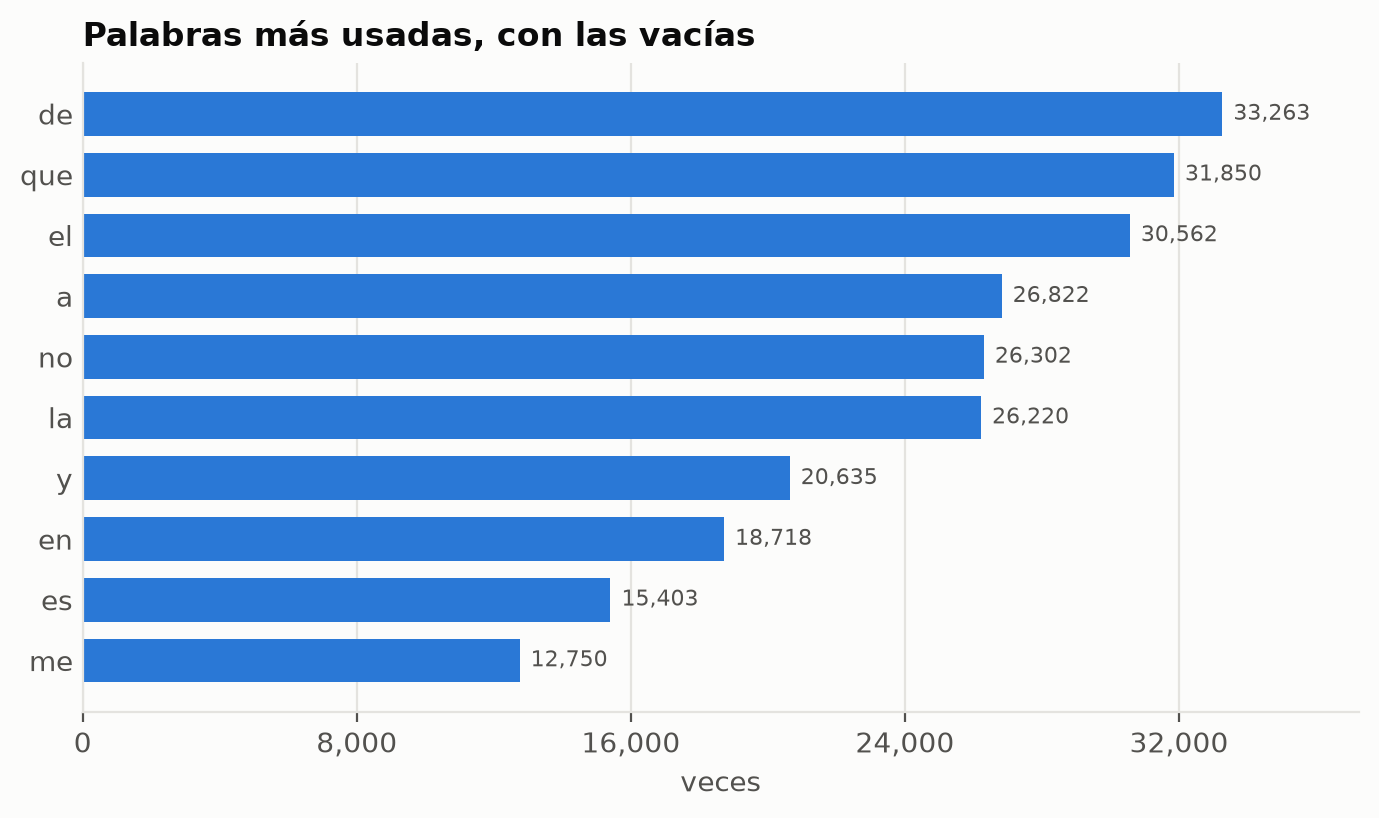

In [ ]:
barh(all_words["palabra"], all_words["veces"], "Palabras más usadas, con las vacías", "veces")

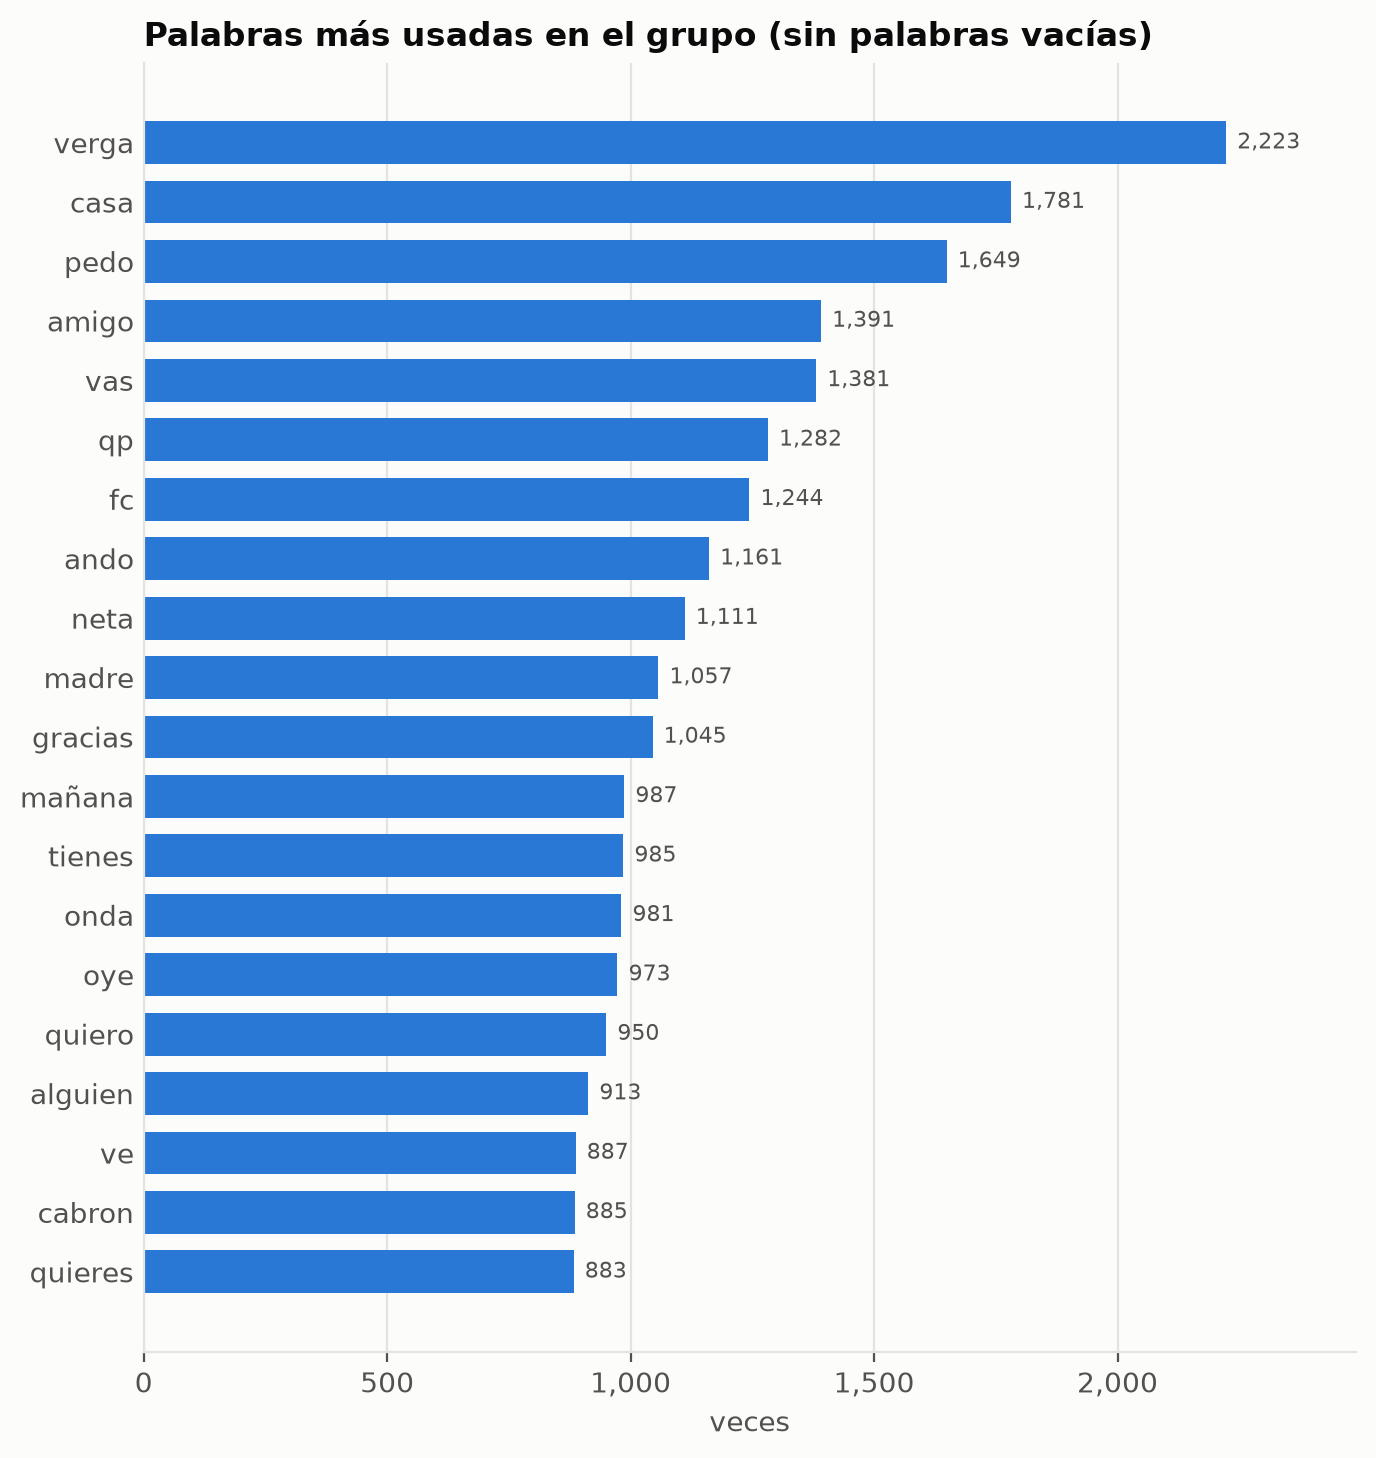

In [ ]:
top_content_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM tokens
    WHERE is_alpha AND NOT is_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con,
    output=False,
)
barh(
    top_content_words["palabra"],
    top_content_words["veces"],
    "Palabras más usadas en el grupo (sin palabras vacías)",
    "veces",
)

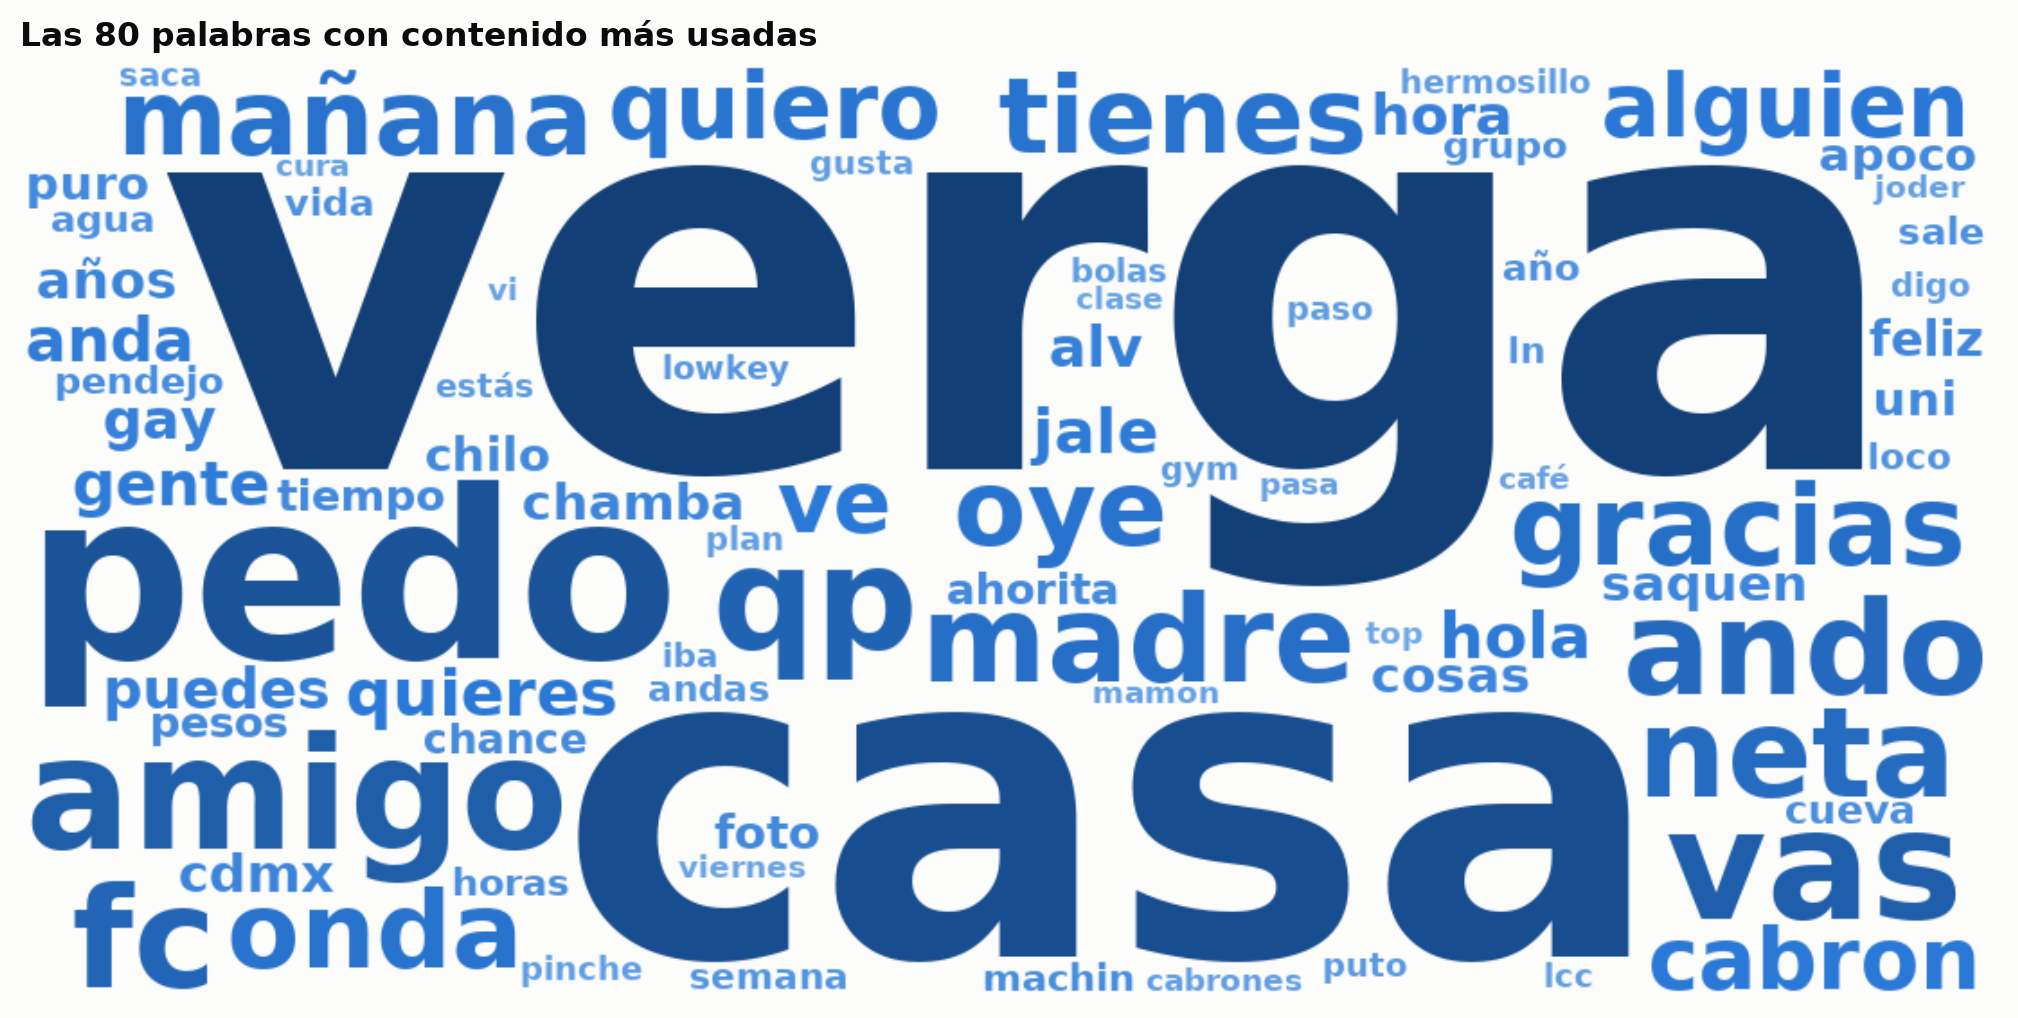

In [ ]:
cloud_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM tokens
    WHERE is_alpha AND NOT is_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 80
    """,
    engine=con,
    output=False,
)
wordcloud(
    cloud_words["palabra"], cloud_words["veces"], "Las 80 palabras con contenido más usadas"
)

In [ ]:
words_by_sender = mo.sql(
    f"""
    WITH por_usuario AS (
        SELECT m.sender, t.token, count(*) AS veces
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
        GROUP BY ALL
    ),
    ordenadas AS (
        SELECT *, row_number() OVER (PARTITION BY sender ORDER BY veces DESC, token) AS lugar
        FROM por_usuario
    )
    SELECT
        sender AS usuario,
        string_agg(token || ' (' || veces || ')', ', ' ORDER BY lugar) AS palabras_mas_usadas
    FROM ordenadas
    WHERE lugar <= 5
    GROUP BY sender
    ORDER BY usuario
    """,
    engine=con
)

usuario,palabras_mas_usadas
"""Aguililla""","""tung (325), verga (316), casa (259), vas (201), qp (197)"""
"""Ajolote""","""bn (78), ola (78), hola (55), casa (43), fc (43)"""
"""Armadillo""","""fc (52), feliz (29), gente (25), hola (25), ando (23)"""
"""Ballena""","""alv (54), ln (38), verga (38), loco (37), agua (36)"""
"""Berrendo""","""casa (48), qp (43), ando (38), gracias (37), fc (36)"""
"""Cacomixtle""","""pedo (244), verga (193), casa (188), alv (186), amigo (167)"""
"""Chachalaca""","""sii (31), casa (28), fc (25), grupo (23), ño (23)"""
"""Cocodrilo""","""años (23), casa (20), chilo (19), alguien (18), arco (17)"""
"""Colibrí""","""gay (253), lowkey (164), ln (127), neta (125), lit (112)"""
"""Correcaminos""","""quieres (127), ayudarte (93), datos (55), estás (55), you (47)"""


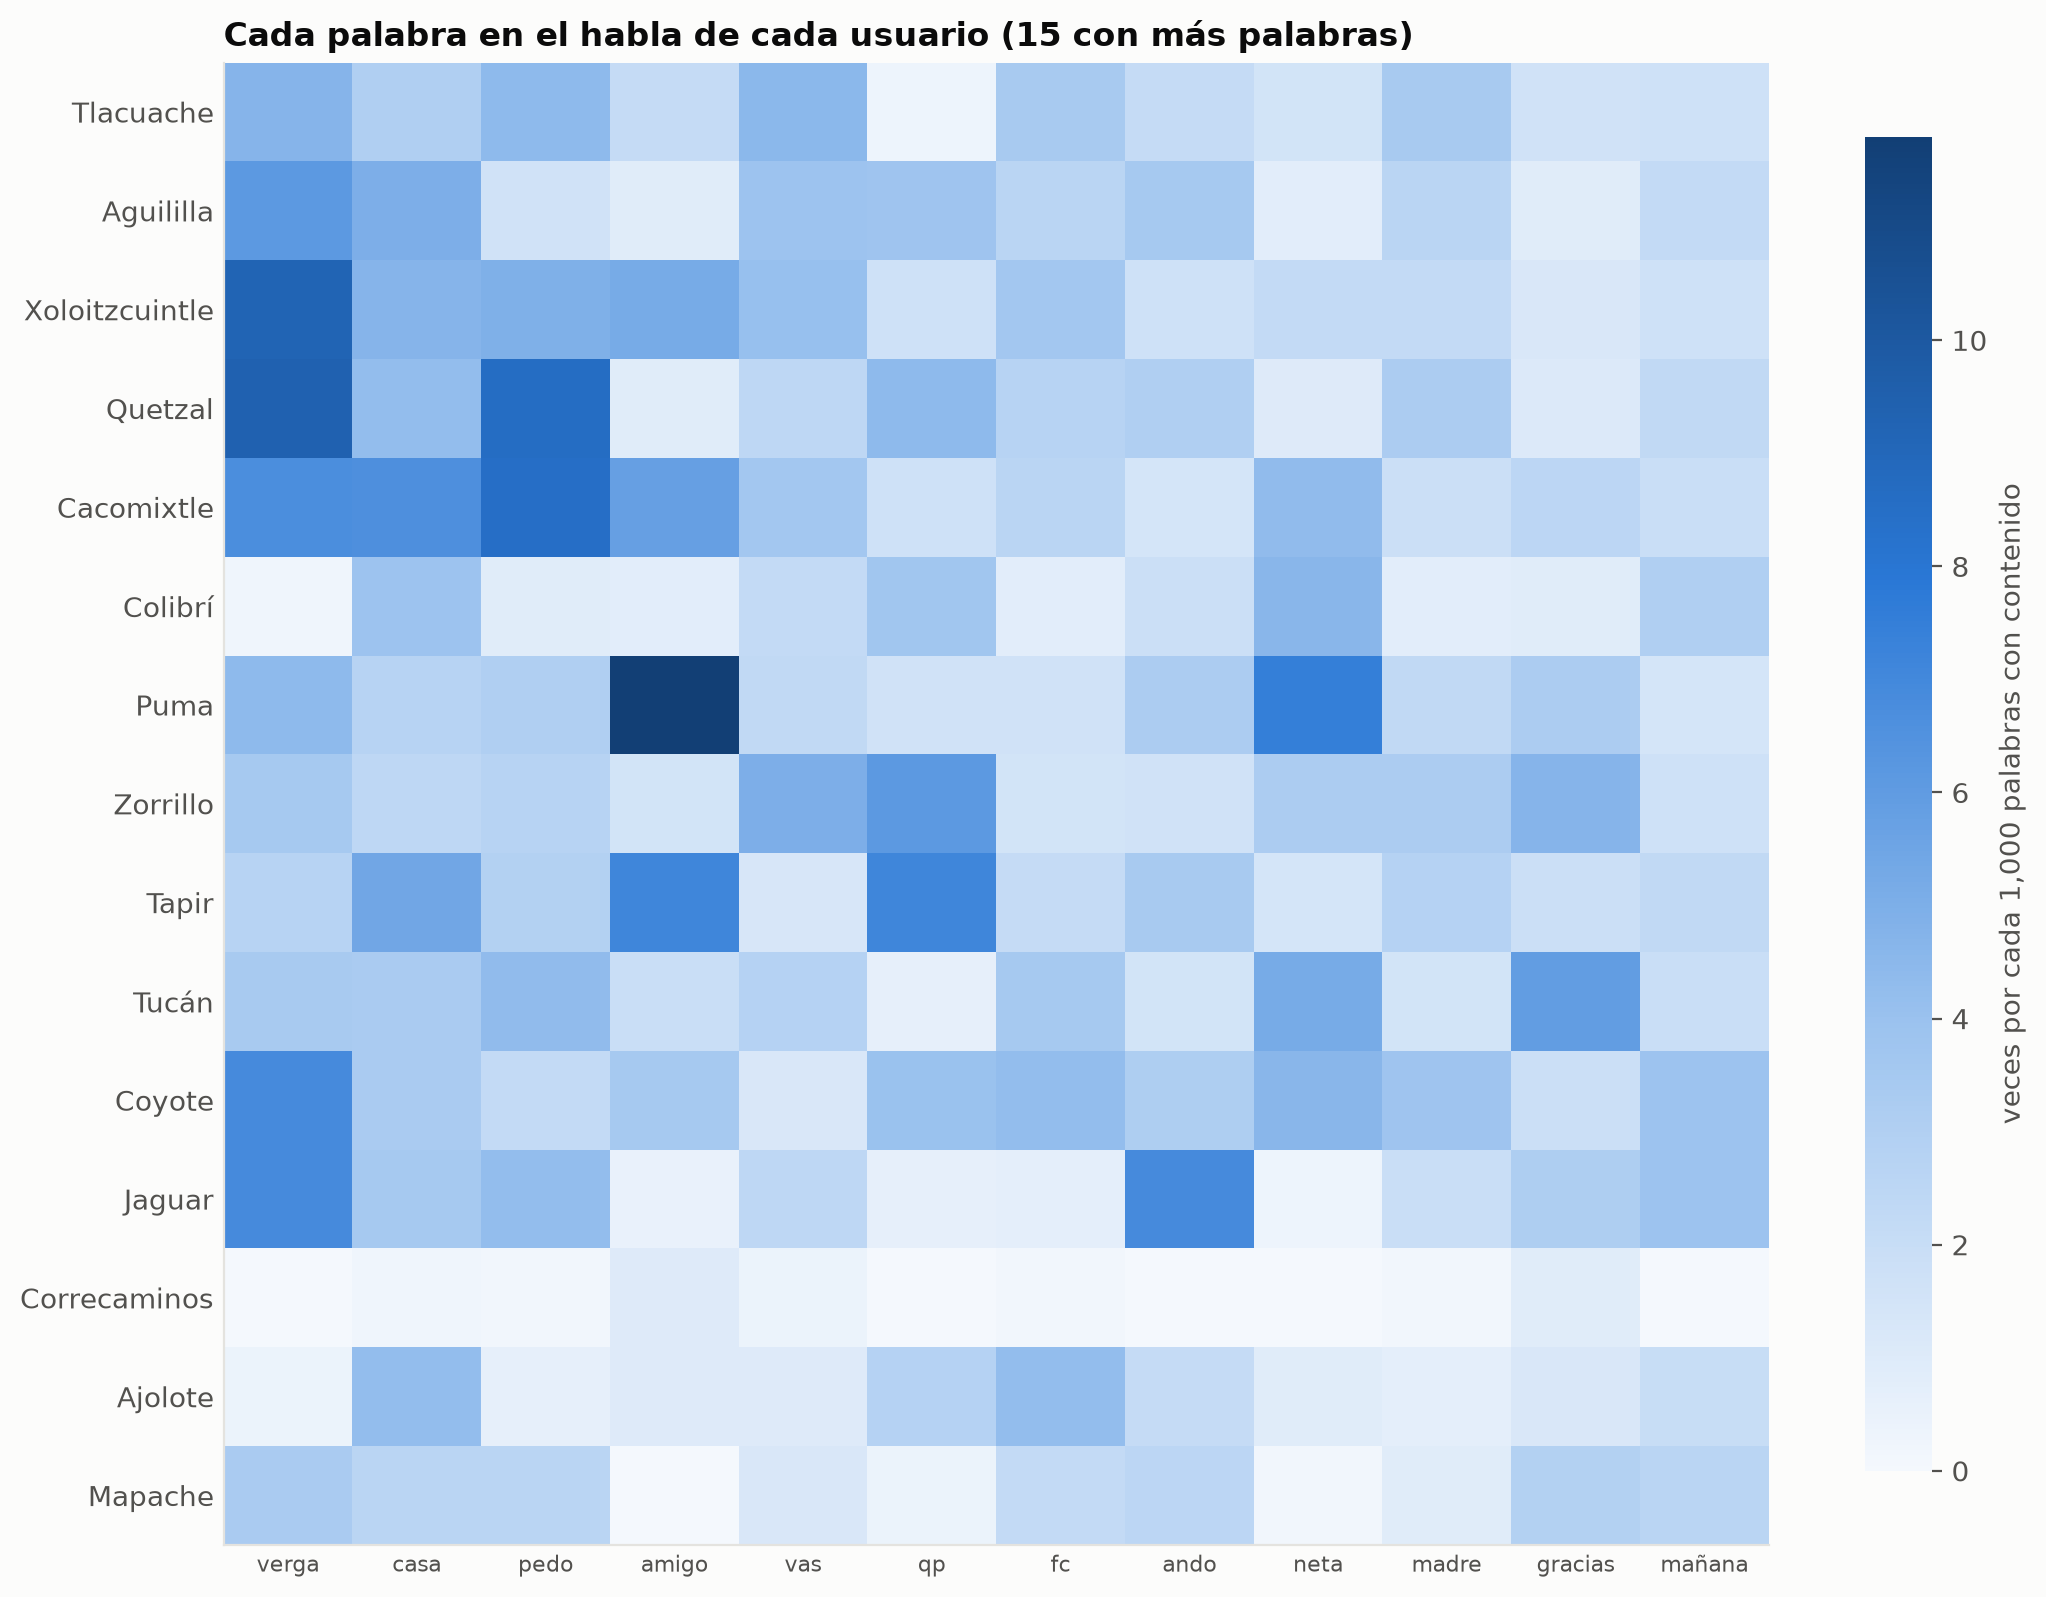

In [ ]:
word_rates = mo.sql(
    f"""
    WITH content AS (
        SELECT m.sender, t.token
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
    ),
    top_words AS (
        SELECT token, row_number() OVER (ORDER BY veces DESC, token) AS lugar
        FROM (SELECT token, count(*) AS veces FROM content GROUP BY token)
        QUALIFY lugar <= 12
    ),
    top_users AS (
        SELECT sender, count(*) AS total
        FROM content
        GROUP BY sender
        ORDER BY total DESC
        LIMIT 15
    )
    SELECT
        u.sender AS usuario,
        w.token AS palabra,
        round(1000 * count(*) / u.total, 1) AS por_mil,
        u.total,
        w.lugar
    FROM content AS c
    JOIN top_users AS u USING (sender)
    JOIN top_words AS w USING (token)
    GROUP BY u.sender, w.token, u.total, w.lugar
    """,
    engine=con,
    output=False,
)
_users = word_rates.unique("usuario").sort("total", descending=True)["usuario"]
_words = word_rates.unique("palabra").sort("lugar")["palabra"]
_rates = {(row["usuario"], row["palabra"]): row["por_mil"] for row in word_rates.iter_rows(named=True)}
heatmap(
    [[_rates.get((user, word), 0) for word in _words] for user in _users],
    _users,
    _words,
    "Cada palabra en el habla de cada usuario (15 con más palabras)",
    "veces por cada 1,000 palabras con contenido",
)

In [ ]:
note(
    "Sin filtrar, las diez palabras más usadas son todas vacías (*de*, *que*, *el*, "
    "*no*...): son las que sostienen cualquier texto en español y no dicen nada del "
    "grupo. Filtrando las vacías (las de spaCy más las muletillas del chat, sección 6) "
    "aparece de qué se habla: las cinco primeras son "
    + ", ".join(
        f"**{row['palabra']}** ({row['veces']:,})"
        for row in top_content_words.head(5).iter_rows(named=True)
    )
    + ". Son sobre todo groserías que en el habla del norte de México funcionan como "
    "muletilla, y palabras de quedar de verse (*casa*, *mañana*, *alguien*): el grupo "
    "se usa para organizar planes más que para conversar de un tema.\n\n"
    "Por usuario, las listas se parecen entre sí en las primeras palabras y se "
    "distinguen después: cada quien tiene sus propias muletillas, y ahí se nota quién "
    "organiza planes, quién habla de futbol y quién de la escuela."
)

Sin filtrar, las diez palabras más usadas son todas vacías ( de , que , el , no ...): son las que sostienen cualquier texto en español y no dicen nada del grupo. Filtrando las vacías (las de spaCy más las muletillas del chat, sección 6) aparece de qué se habla: las cinco primeras son verga (2,223), casa (1,781), pedo (1,649), amigo (1,391), vas (1,381). Son sobre todo groserías que en el habla del norte de México funcionan como muletilla, y palabras de quedar de verse ( casa , mañana , alguien ): el grupo se usa para organizar planes más que para conversar de un tema. 
 Por usuario, las listas se parecen entre sí en las primeras palabras y se distinguen después: cada quien tiene sus propias muletillas, y ahí se nota quién organiza planes, quién habla de futbol y quién de la escuela.

## 14. ¿Cuáles son los adjetivos más usados?

Por lema, para juntar *buena*, *buenas* y *bueno*. Aquí no se filtran las palabras
vacías: la lista de spaCy incluye justo los adjetivos más comunes (sección 7).

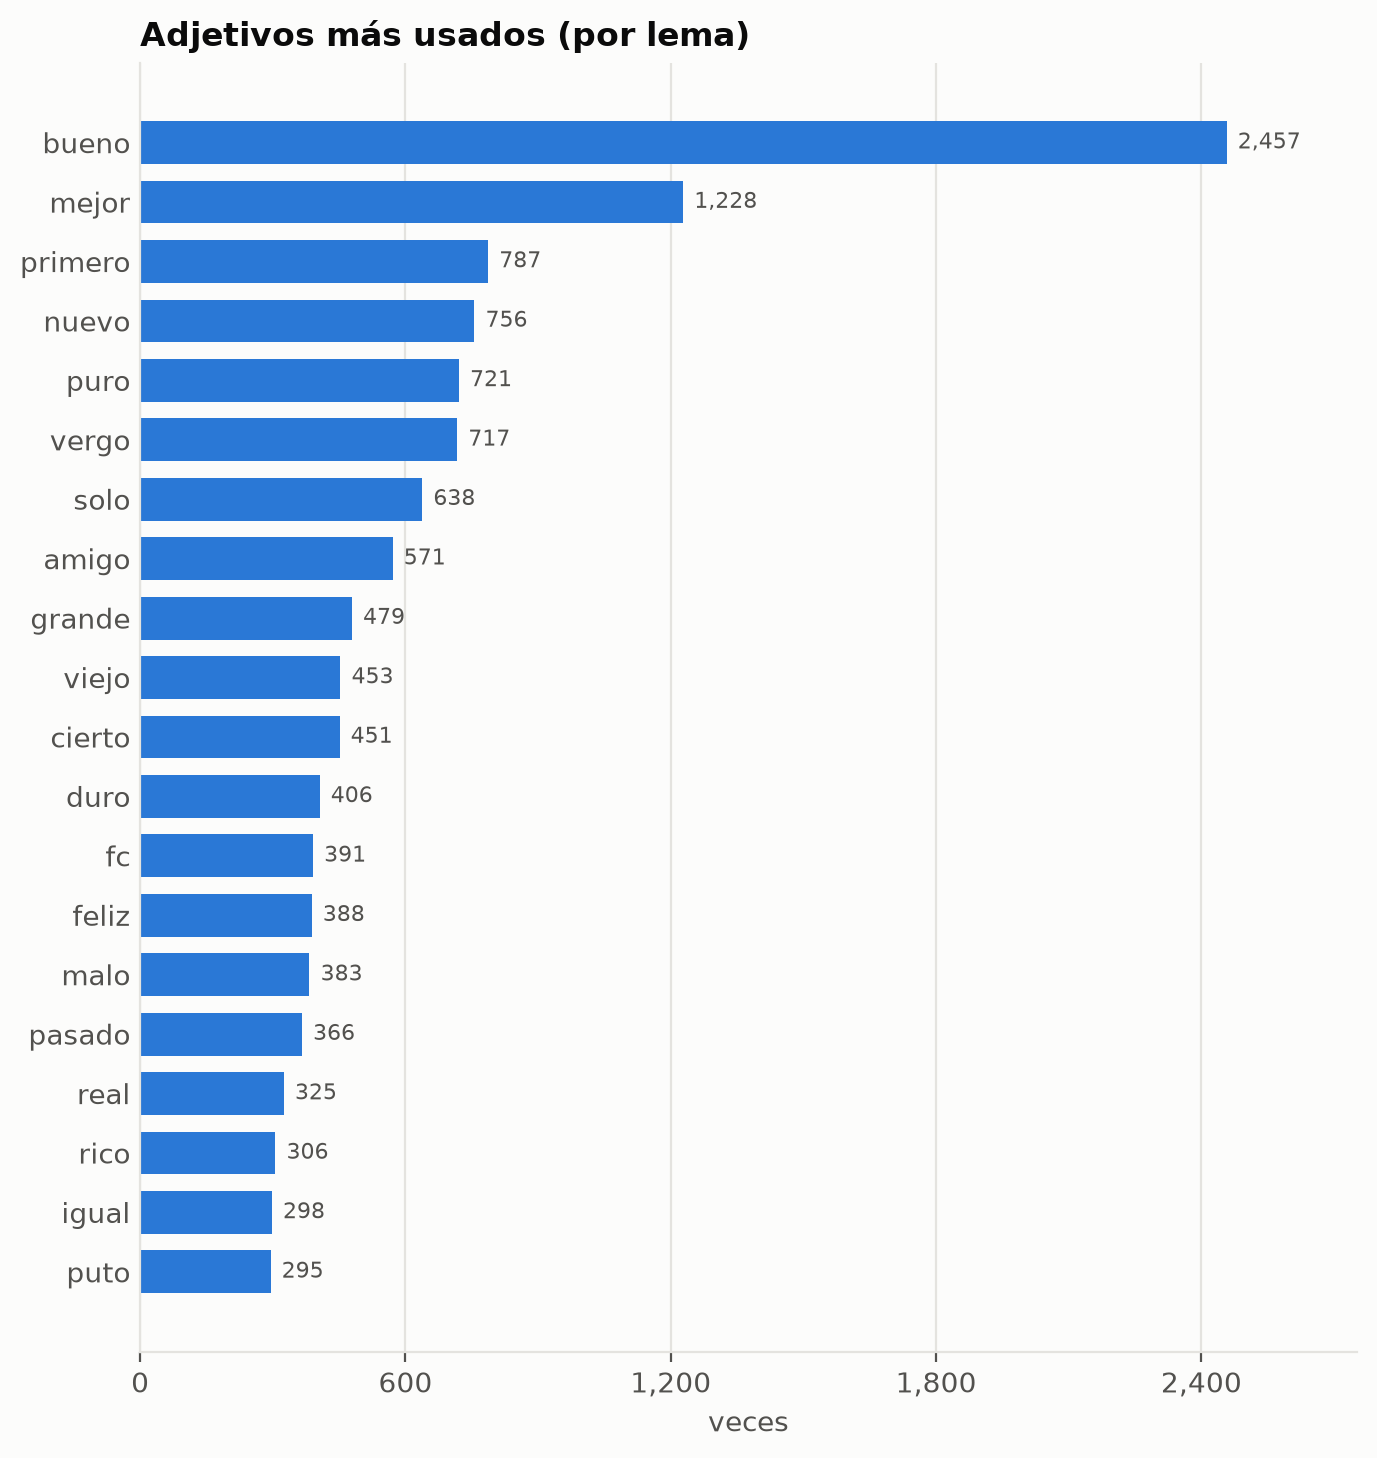

In [ ]:
top_adjectives = mo.sql(
    f"""
    SELECT lemma AS adjetivo, count(*) AS veces
    FROM tokens
    WHERE pos = 'ADJ' AND is_alpha AND NOT is_laugh AND length(token) > 1
    GROUP BY lemma
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con,
    output=False,
)
barh(top_adjectives["adjetivo"], top_adjectives["veces"], "Adjetivos más usados (por lema)", "veces")

In [ ]:
note(
    f"El adjetivo más usado es **{top_adjectives['adjetivo'][0]}** "
    f"({top_adjectives['veces'][0]:,} veces), seguido de {top_adjectives['adjetivo'][1]} y "
    f"{top_adjectives['adjetivo'][2]}. Son adjetivos de valoración —bueno, mejor, nuevo— "
    "más los que este grupo usa para calificarlo todo, incluidas varias groserías que "
    "en el español de México funcionan como adjetivos.\n\n"
    "Hay que leer la lista con reserva: `es_core_news_sm` se entrenó con noticias, y "
    "en un chat sin puntuación confunde sustantivos y verbos con adjetivos (sección "
    "7). Los primeros lugares son sólidos; hacia el final de la lista aparecen "
    "palabras mal etiquetadas."
)

El adjetivo más usado es bueno (2,457 veces), seguido de mejor y primero. Son adjetivos de valoración —bueno, mejor, nuevo— más los que este grupo usa para calificarlo todo, incluidas varias groserías que en el español de México funcionan como adjetivos. 
 Hay que leer la lista con reserva: es_core_news_sm se entrenó con noticias, y en un chat sin puntuación confunde sustantivos y verbos con adjetivos (sección 7). Los primeros lugares son sólidos; hacia el final de la lista aparecen palabras mal etiquetadas.

---

# Parte 3: el tiempo, las conversaciones y las palabras propias

Más preguntas sobre los mismos tres conjuntos de silver: cómo cambia el grupo mes a
mes, cómo se arman las conversaciones y qué palabras distinguen a cada quien.

## 15. ¿Cómo ha evolucionado el grupo?

Mensajes por mes. Los meses a medias (el de la primera y el de la última fecha de la
exportación) van con el punto vacío: no son comparables con los completos.

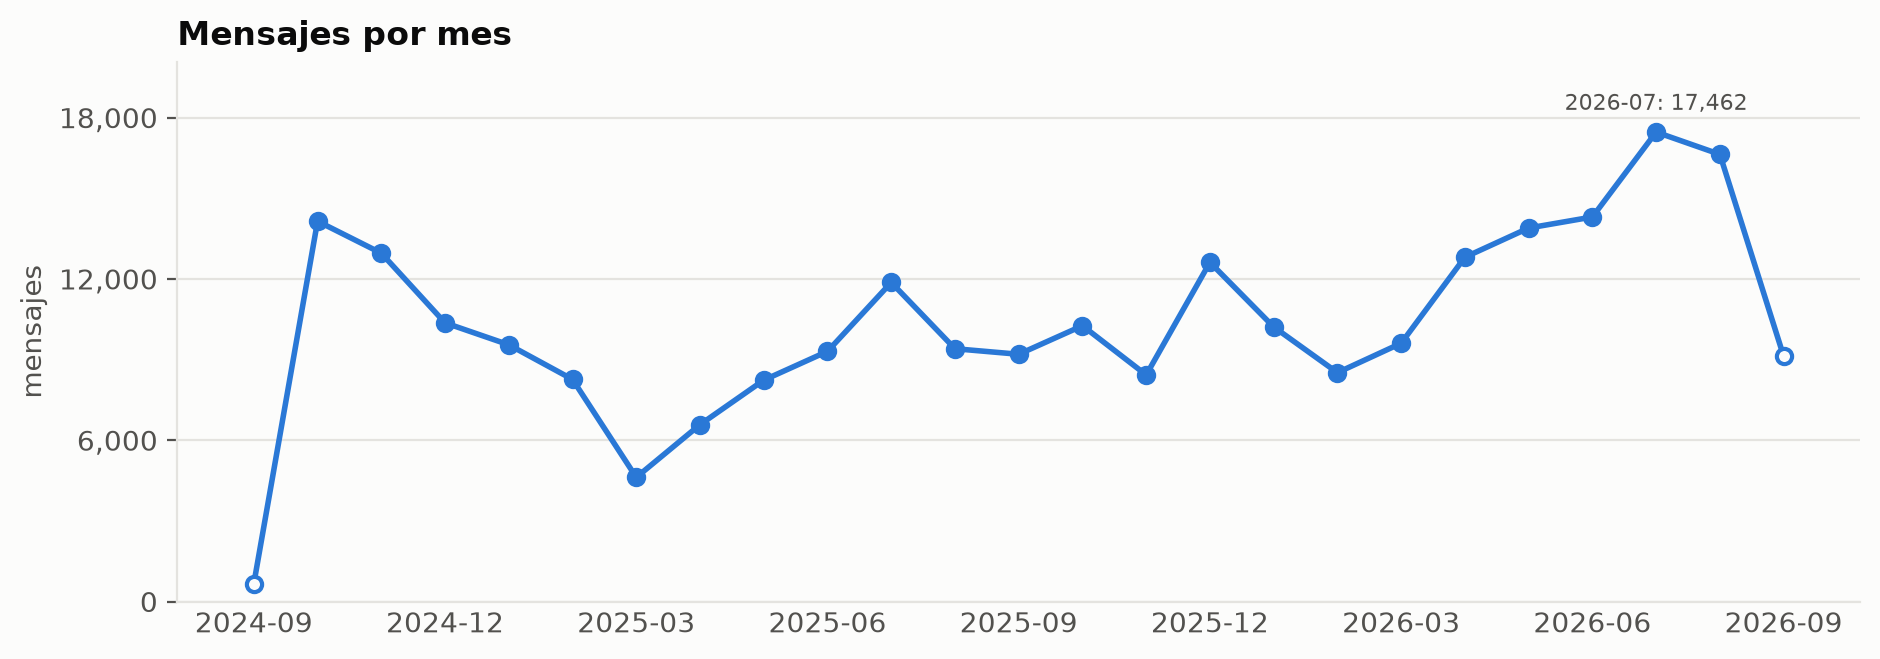

In [ ]:
by_month = mo.sql(
    f"""
    SELECT
        strftime(date_trunc('month', timestamp), '%Y-%m') AS mes,
        count(*) AS mensajes,
        count(DISTINCT sender) AS personas,
        count(DISTINCT timestamp::DATE) AS dias_con_mensajes,
        count(DISTINCT timestamp::DATE) < day(last_day(min(timestamp)::DATE)) AS incompleto
    FROM messages
    GROUP BY mes
    ORDER BY mes
    """,
    engine=con,
    output=False,
)
line(
    by_month["mes"],
    by_month["mensajes"],
    "Mensajes por mes",
    "mensajes",
    every=3,
    hollow=[i for i, partial in enumerate(by_month["incompleto"]) if partial],
    label_peak=True,
)

In [ ]:
_full = by_month.filter(~by_month["incompleto"])
_peak = _full.sort("mensajes", descending=True).row(0, named=True)
_low = _full.sort("mensajes").row(0, named=True)
_first, _last = _full.row(0, named=True), _full.row(-1, named=True)
note(
    f"Entre los {len(_full)} meses completos, el más activo es **{_peak['mes']}** "
    f"({_peak['mensajes']:,} mensajes) y el más callado **{_low['mes']}** "
    f"({_low['mensajes']:,}): {_peak['mensajes'] / _low['mensajes']:.1f} veces de "
    f"diferencia. El grupo empezó en **{_first['mes']}** con {_first['mensajes']:,} "
    f"mensajes, bajó y volvió a subir, y en el último mes completo ({_last['mes']}) "
    f"llegó a {_last['mensajes']:,}. La cantidad de personas que escriben en un mes "
    f"casi no cambia (entre {_full['personas'].min()} y {_full['personas'].max()}): "
    "lo que sube y baja es cuánto habla el mismo grupo, no cuántos son."
)

Entre los 23 meses completos, el más activo es 2026-07 (17,462 mensajes) y el más callado 2025-03 (4,619): 3.8 veces de diferencia. El grupo empezó en 2024-10 con 14,147 mensajes, bajó y volvió a subir, y en el último mes completo (2026-08) llegó a 16,633. La cantidad de personas que escriben en un mes casi no cambia (entre 28 y 34): lo que sube y baja es cuánto habla el mismo grupo, no cuántos son.

## 16. ¿Quién inicia y quién cierra las conversaciones?

Una **sesión** es una racha de mensajes sin pausas de más de 30 minutos: cada pausa
más larga abre una sesión nueva. Se cuentan todos los mensajes de personas (también
stickers y fotos), en orden de fecha. Quien **inicia** es quien manda el primer
mensaje de la sesión y quien **cierra**, el último. Para esto solo cuentan las
sesiones de al menos 2 mensajes: un mensaje que nadie contestó en media hora no es una
conversación (se reportan aparte).

In [ ]:
sessions = con.sql(
    """
    WITH ordered AS (
        SELECT
            message_id, timestamp, sender,
            coalesce(timestamp - lag(timestamp) OVER w > INTERVAL 30 MINUTE, true) AS nueva
        FROM messages
        WHERE sender IS NOT NULL
        WINDOW w AS (ORDER BY timestamp, message_id)
    ),
    marked AS (
        SELECT *, sum(nueva::INT) OVER (ORDER BY timestamp, message_id) AS sesion FROM ordered
    )
    SELECT
        sesion,
        min(timestamp) AS desde,
        count(*) AS mensajes,
        count(DISTINCT sender) AS personas,
        arg_min(sender, (timestamp, message_id)) AS inicia,
        arg_max(sender, (timestamp, message_id)) AS cierra,
        date_diff('minute', min(timestamp), max(timestamp)) AS minutos
    FROM marked
    GROUP BY sesion
    """
).pl()
con.register("sessions", sessions)
note(f"Sesiones: **{len(sessions):,}**")

Sesiones: 5,633

In [ ]:
session_summary = mo.sql(
    f"""
    SELECT
        count(*) AS sesiones,
        count(*) FILTER (mensajes = 1) AS de_un_mensaje,
        count(*) FILTER (mensajes >= 2) AS conversaciones,
        median(mensajes) FILTER (mensajes >= 2) AS mediana_mensajes,
        median(minutos) FILTER (mensajes >= 2) AS mediana_minutos,
        max(mensajes) AS la_mas_larga_mensajes,
        max(minutos) AS la_mas_larga_minutos
    FROM sessions
    """,
    engine=con
)

sesiones,de_un_mensaje,conversaciones,mediana_mensajes,mediana_minutos,la_mas_larga_mensajes,la_mas_larga_minutos
5633,642,4991,16.0,31.0,1958,681


In [ ]:
openers = mo.sql(
    f"""
    WITH abre AS (
        SELECT inicia AS usuario, count(*) AS n FROM sessions WHERE mensajes >= 2 GROUP BY 1
    ),
    cierra AS (
        SELECT cierra AS usuario, count(*) AS n FROM sessions WHERE mensajes >= 2 GROUP BY 1
    ),
    enviados AS (
        SELECT sender AS usuario, count(*) AS n FROM messages WHERE sender IS NOT NULL GROUP BY 1
    )
    SELECT
        e.usuario,
        coalesce(a.n, 0) AS abre,
        coalesce(c.n, 0) AS cierra,
        e.n AS mensajes,
        round(1000.0 * coalesce(a.n, 0) / e.n, 1) AS abre_por_mil_mensajes
    FROM enviados AS e
    LEFT JOIN abre AS a USING (usuario)
    LEFT JOIN cierra AS c USING (usuario)
    ORDER BY abre DESC
    """,
    engine=con
)

usuario,abre,cierra,mensajes,abre_por_mil_mensajes
"""Tlacuache""",737,701,34554,21.3
"""Quetzal""",383,323,17787,21.5
"""Aguililla""",378,845,32717,11.6
"""Puma""",275,202,15450,17.8
"""Jaguar""",258,393,10790,23.9
"""Coyote""",252,218,9430,26.7
"""Cacomixtle""",244,227,19066,12.8
"""Colibrí""",239,119,13758,17.4
"""Tapir""",234,166,12794,18.3
"""Mapache""",196,126,3756,52.2


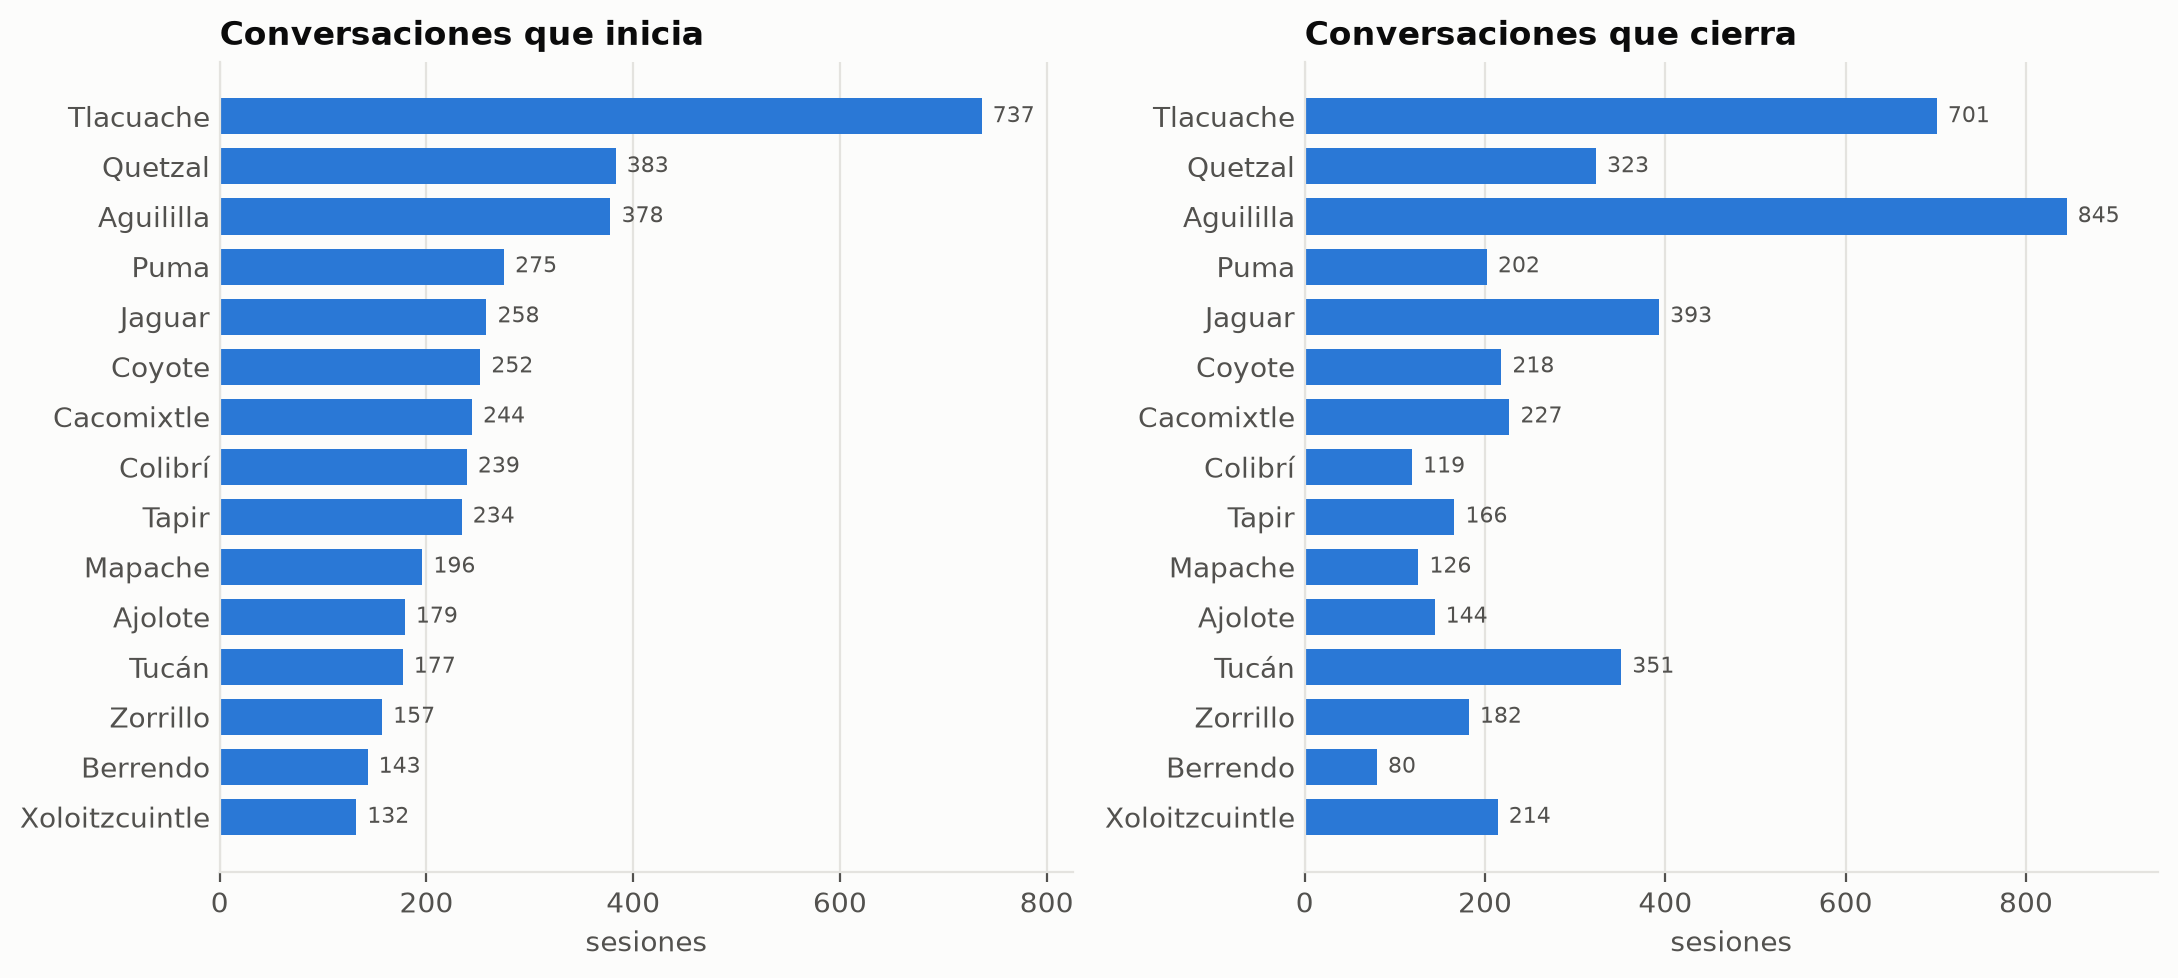

In [ ]:
_top = openers.head(15)
_fig, _axes = plt.subplots(1, 2, figsize=(11, 5))
barh(_top["usuario"], _top["abre"], "Conversaciones que inicia", "sesiones", ax=_axes[0])
barh(_top["usuario"], _top["cierra"], "Conversaciones que cierra", "sesiones", ax=_axes[1])
_fig

In [ ]:
session_sizes = mo.sql(
    f"""
    SELECT
        CASE
            WHEN mensajes = 1 THEN '1'
            WHEN mensajes = 2 THEN '2'
            WHEN mensajes <= 5 THEN '3-5'
            WHEN mensajes <= 10 THEN '6-10'
            WHEN mensajes <= 20 THEN '11-20'
            WHEN mensajes <= 50 THEN '21-50'
            WHEN mensajes <= 100 THEN '51-100'
            ELSE '100+'
        END AS mensajes_por_sesion,
        min(mensajes) AS orden,
        count(*) AS sesiones
    FROM sessions
    GROUP BY 1
    ORDER BY orden
    """,
    output=False,
    engine=con
)

In [ ]:
session_lengths = mo.sql(
    f"""
    SELECT
        CASE
            WHEN minutos < 5 THEN '<5 min'
            WHEN minutos < 15 THEN '5-15 min'
            WHEN minutos < 30 THEN '15-30 min'
            WHEN minutos < 60 THEN '30-60 min'
            WHEN minutos < 120 THEN '1-2 h'
            WHEN minutos < 240 THEN '2-4 h'
            WHEN minutos < 480 THEN '4-8 h'
            ELSE '8 h+'
        END AS duracion,
        min(minutos) AS orden,
        count(*) AS sesiones
    FROM sessions
    WHERE mensajes >= 2
    GROUP BY 1
    ORDER BY orden
    """,
    output=False,
    engine=con
)

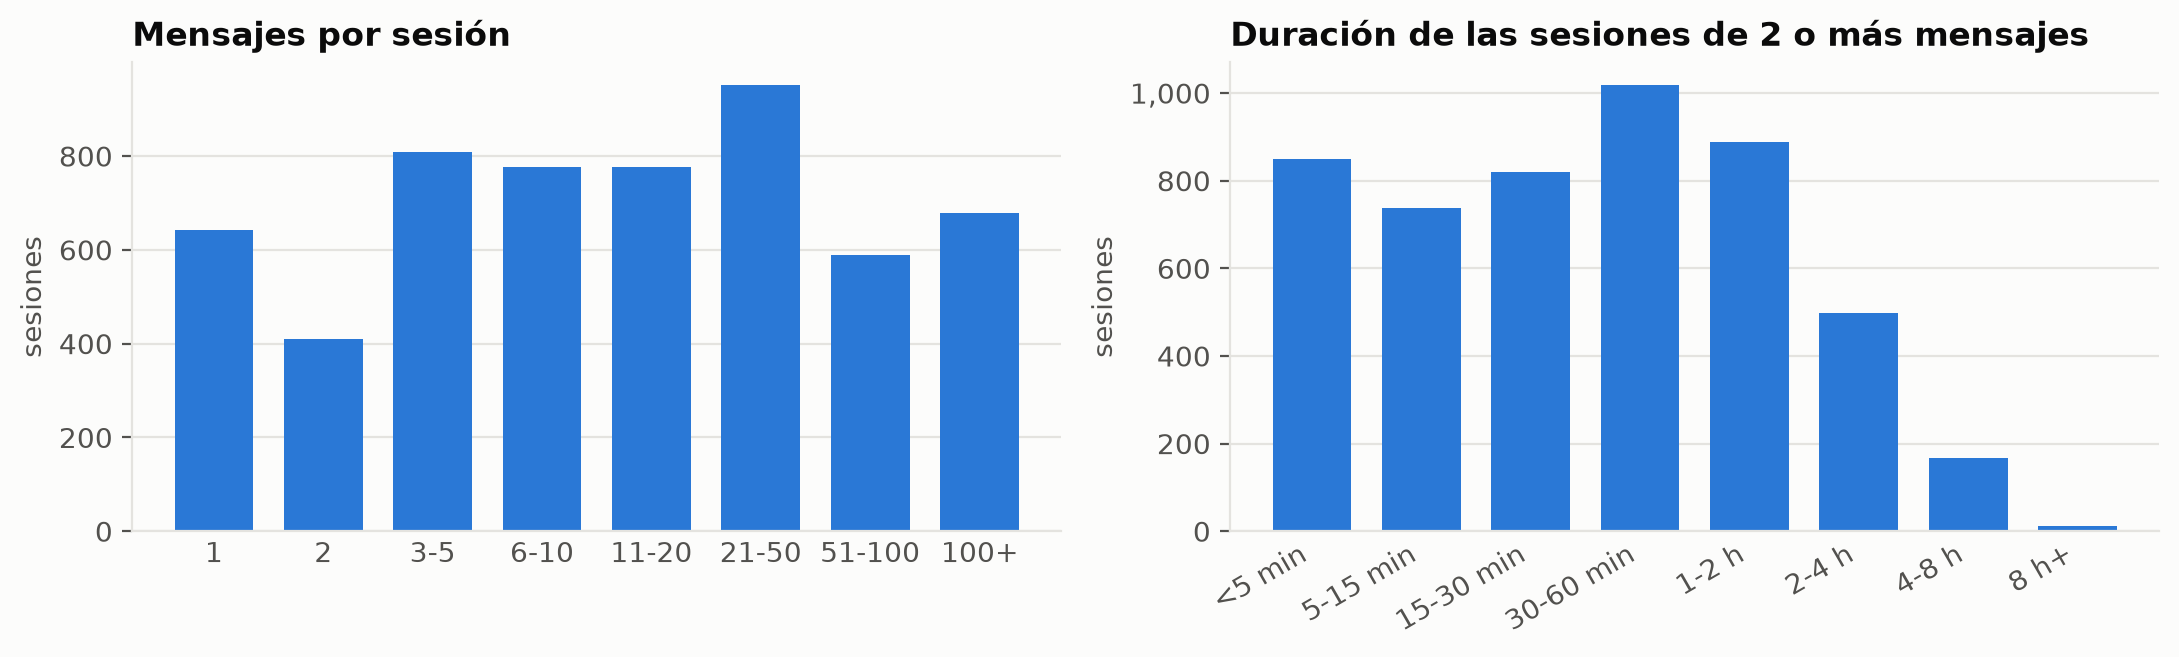

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.4))
columns(
    session_sizes["mensajes_por_sesion"],
    session_sizes["sesiones"],
    "Mensajes por sesión",
    "sesiones",
    ax=_axes[0],
)
columns(
    session_lengths["duracion"],
    session_lengths["sesiones"],
    "Duración de las sesiones de 2 o más mensajes",
    "sesiones",
    rotate=30,
    ax=_axes[1],
)
_fig

In [ ]:
_s = session_summary.row(0, named=True)
_opens = openers.sort("abre", descending=True)
_closes = openers.sort("cierra", descending=True)
_rate = openers.filter(openers["mensajes"] >= 1000).sort(
    "abre_por_mil_mensajes", descending=True
)
note(
    f"Con pausas de 30 minutos, el grupo se reparte en **{_s['sesiones']:,} sesiones**: "
    f"{_s['de_un_mensaje']:,} son de un solo mensaje que nadie contestó en media hora, y "
    f"las otras {_s['conversaciones']:,} son "
    f"conversaciones de {_s['mediana_mensajes']:.0f} mensajes y {_s['mediana_minutos']:.0f} "
    f"minutos en la mediana (la más larga tiene {_s['la_mas_larga_mensajes']:,} mensajes "
    f"a lo largo de {_s['la_mas_larga_minutos'] / 60:.0f} horas). Los rangos de las "
    "gráficas de arriba no tienen el mismo ancho: cada barra cuenta cuántas sesiones "
    "caen en su rango, no es una densidad."
    f"\n\n**{_opens['usuario'][0]}** inicia más conversaciones ({_opens['abre'][0]:,}), "
    f"seguido de {_opens['usuario'][1]} ({_opens['abre'][1]:,}); **{_closes['usuario'][0]}** "
    f"las cierra más ({_closes['cierra'][0]:,}), seguido de {_closes['usuario'][1]} "
    f"({_closes['cierra'][1]:,}). Como quien más escribe tiene más oportunidades de "
    f"abrir y de cerrar, la última columna de la tabla normaliza: por cada mil mensajes "
    f"que manda, quien más inicia (entre quienes mandan al menos mil) es "
    f"**{_rate['usuario'][0]}**, con {_rate['abre_por_mil_mensajes'][0]} sesiones."
)

Con pausas de 30 minutos, el grupo se reparte en 5,633 sesiones : 642 son de un solo mensaje que nadie contestó en media hora, y las otras 4,991 son conversaciones de 16 mensajes y 31 minutos en la mediana (la más larga tiene 1,958 mensajes a lo largo de 11 horas). Los rangos de las gráficas de arriba no tienen el mismo ancho: cada barra cuenta cuántas sesiones caen en su rango, no es una densidad. 
 Tlacuache inicia más conversaciones (737), seguido de Quetzal (383); Aguililla las cierra más (845), seguido de Tlacuache (701). Como quien más escribe tiene más oportunidades de abrir y de cerrar, la última columna de la tabla normaliza: por cada mil mensajes que manda, quien más inicia (entre quienes mandan al menos mil) es Armadillo , con 61.0 sesiones.

## 17. ¿Qué palabras distinguen a cada persona?

Las palabras más usadas de cada quien se parecen (sección 13); lo que lo distingue es
lo que dice él o ella y casi nadie más. Se mide con **TF-IDF**: cada persona es un
"documento" hecho de todas sus palabras con contenido; el **TF** es cuánto usa una
palabra entre las suyas, y el **IDF** (`ln(N / df)`, con `N` personas y `df` las que
la usan) pesa más las palabras que pocos usan y cero las que usan todos. Así una
palabra sube cuando esa persona la usa mucho y el resto poco.

Para no premiar erratas ni chistes de una sola vez, solo entran las personas con al
menos 2,000 palabras con contenido, las palabras usadas 50 veces o más en el grupo y
las que esa persona escribió al menos 10 veces.

In [ ]:
distinctive = mo.sql(
    f"""
    WITH content AS (
        SELECT m.sender, t.token
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
    ),
    users AS (
        SELECT sender, count(*) AS total FROM content GROUP BY sender HAVING count(*) >= 2000
    ),
    per_user AS (
        SELECT sender, token, count(*) AS veces
        FROM content JOIN users USING (sender)
        GROUP BY sender, token
    ),
    words AS (
        SELECT token, count(*) AS personas FROM per_user GROUP BY token HAVING sum(veces) >= 50
    ),
    scored AS (
        SELECT
            p.sender AS usuario,
            p.token AS palabra,
            p.veces,
            w.personas AS personas_que_la_usan,
            u.total,
            p.veces::DOUBLE / u.total * ln((SELECT count(*) FROM users)::DOUBLE / w.personas) AS tfidf
        FROM per_user AS p
        JOIN users AS u USING (sender)
        JOIN words AS w USING (token)
        WHERE p.veces >= 10
    )
    SELECT *, row_number() OVER (PARTITION BY usuario ORDER BY tfidf DESC, palabra) AS lugar
    FROM scored
    QUALIFY lugar <= 8
    ORDER BY usuario, lugar
    """,
    engine=con,
    output=False,
)
(
    distinctive.filter(pl.col("lugar") <= 6)
    .group_by("usuario", maintain_order=True)
    .agg(
        pl.format("{} ({})", pl.col("palabra"), pl.col("veces"))
        .str.join(", ")
        .alias("palabras_distintivas")
    )
)

usuario,palabras_distintivas
"""Aguililla""","""tung (325), lnt (130), toink (104), dedlok (117), bn (85), jeju (53)"""
"""Ajolote""","""bn (78), qn (31), ola (78), esque (13), jare (27), deadlock (38)"""
"""Armadillo""","""gym (17), joder (11), ei (12), fc (52), cumpleaños (11), neta (12)"""
"""Ballena""","""didcom (18), inglaterra (26), messi (23), ln (38), argentina (26), alv (54)"""
"""Berrendo""","""wa (27), deadlock (31), eu (13), sienna (11), machín (20), ln (26)"""
"""Cacomixtle""","""ylv (69), alv (186), mames (57), radical (26), aah (15), hey (56)"""
"""Chachalaca""","""sii (31), boda (13), shi (10), gym (13), pan (11), gpi (17)"""
"""Cocodrilo""","""arco (17), tema (13), cv (13), experiencia (11), saquen (17), the (17)"""
"""Colibrí""","""pdv (82), tho (73), lit (112), daddy (61), ln (127), colibrí (74)"""
"""Correcaminos""","""ayudarte (93), neovim (31), solicitud (31), with (42), or (27), epstein (35)"""


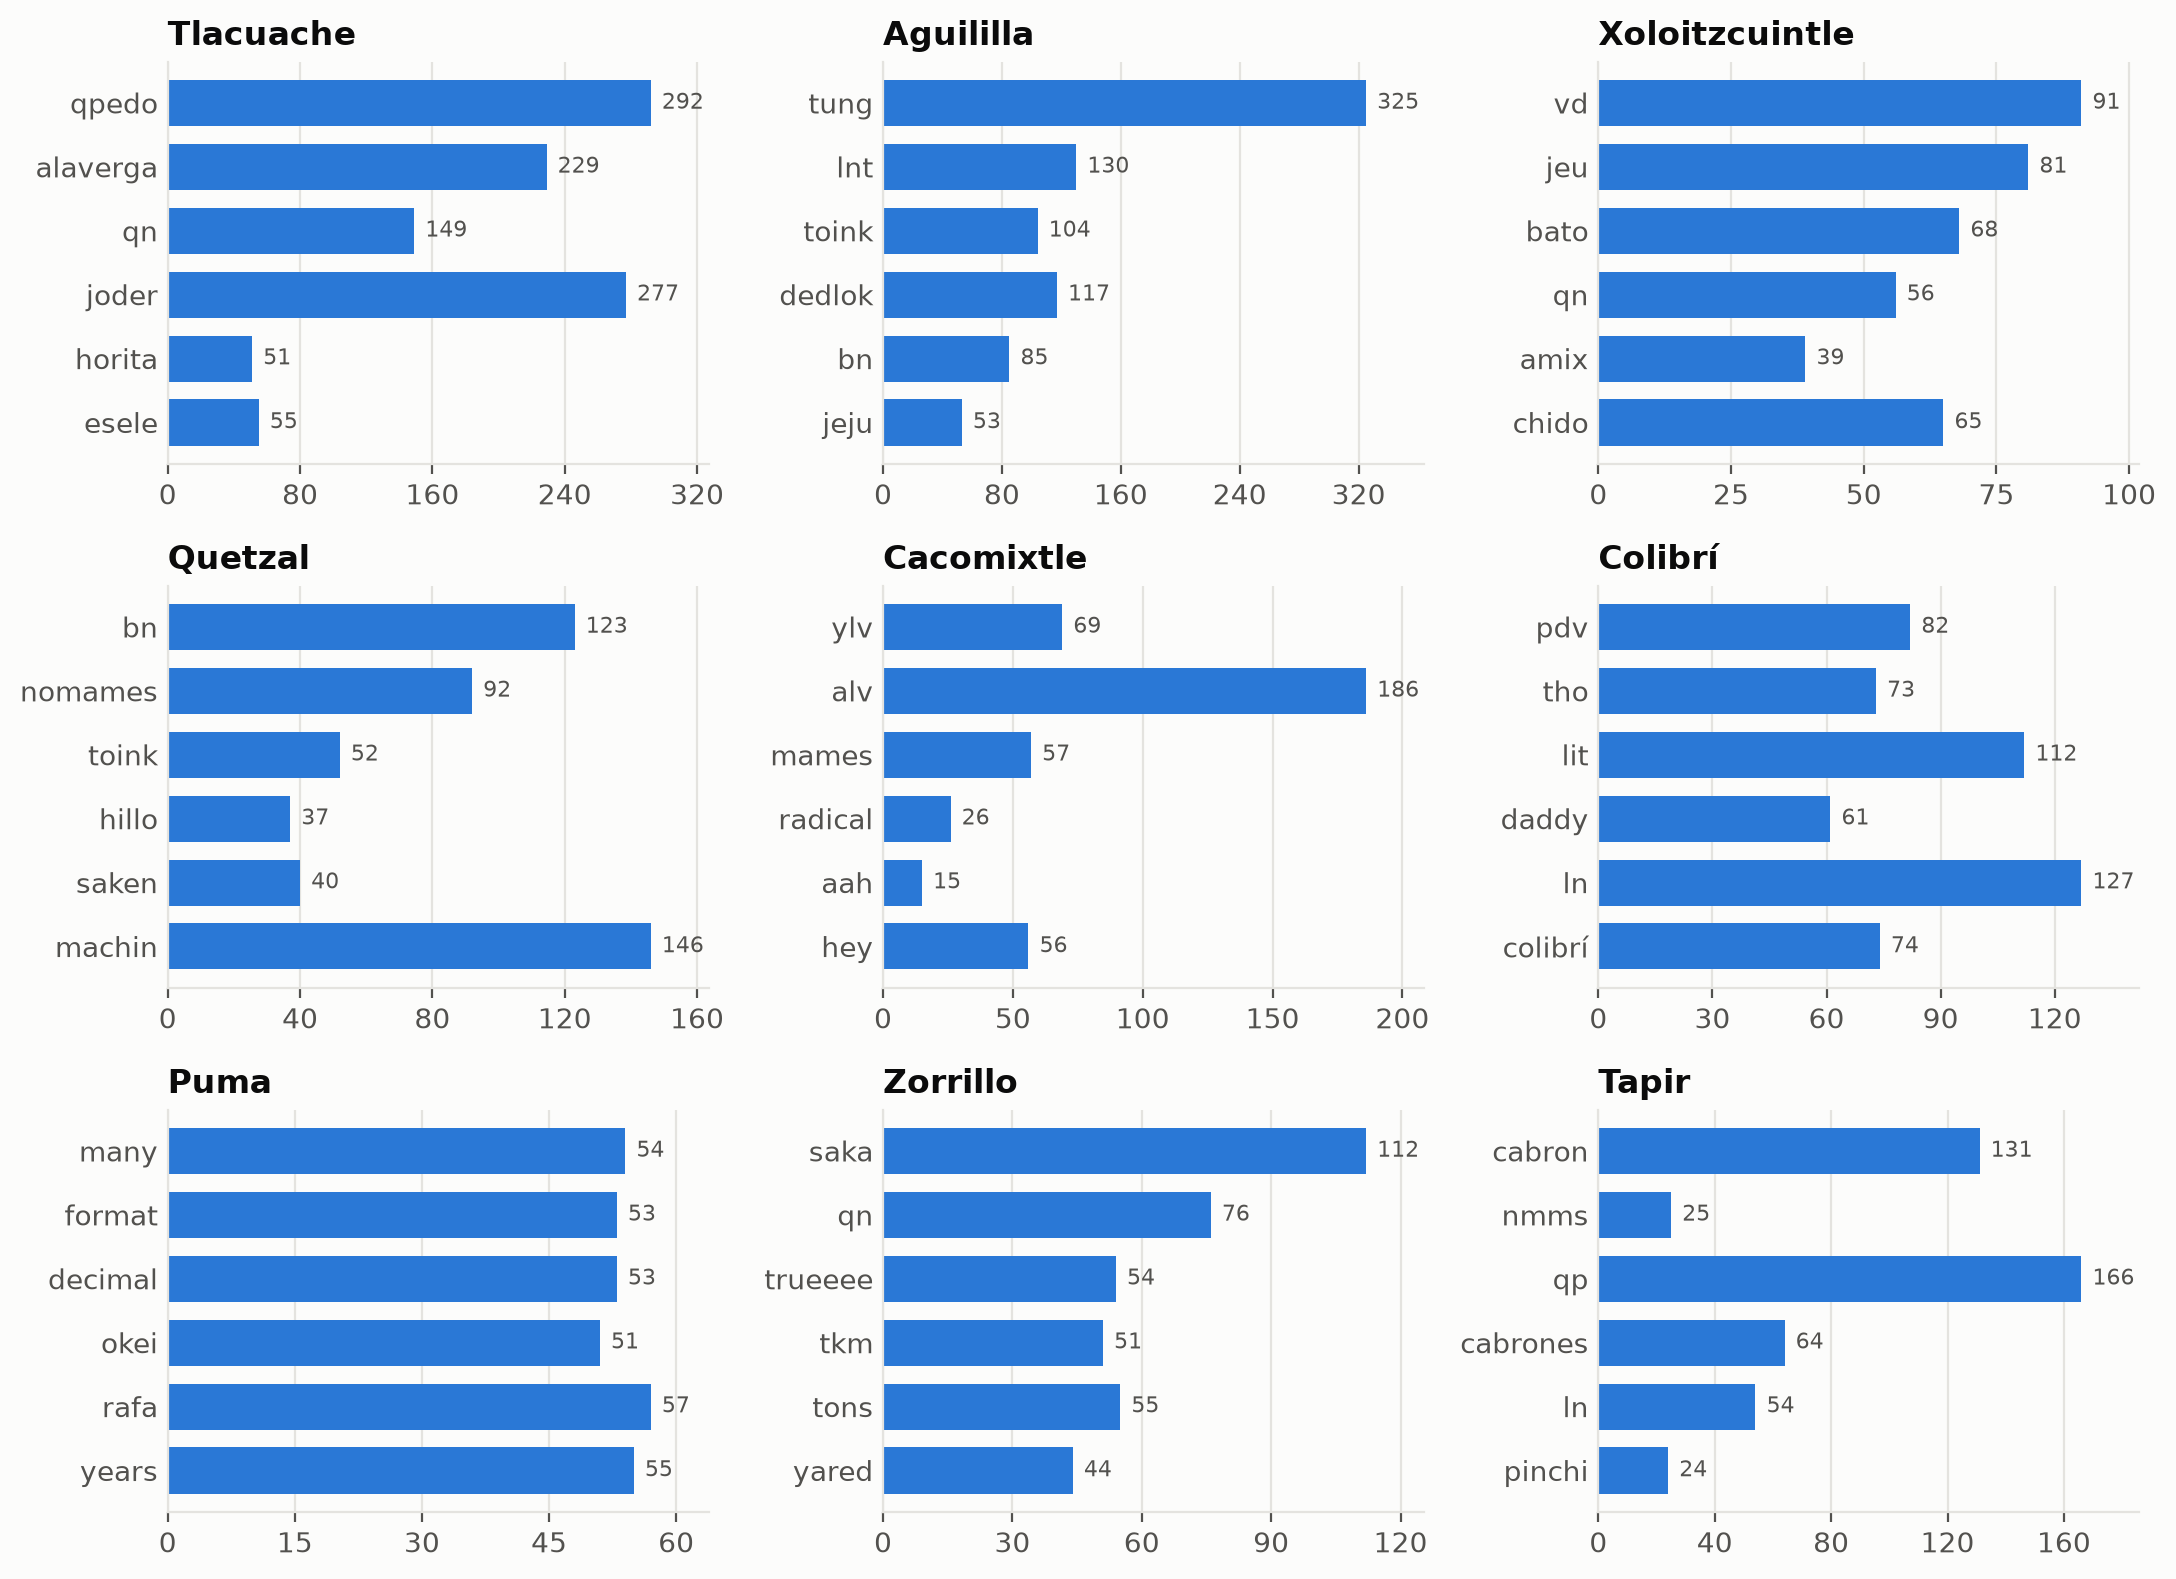

In [ ]:
_users = distinctive.unique("usuario").sort("total", descending=True)["usuario"][:9]
_fig, _axes = plt.subplots(3, 3, figsize=(11, 8))
for _ax, _user in zip(_axes.flat, _users):
    _words = distinctive.filter(pl.col("usuario") == _user).head(6)
    barh(_words["palabra"], _words["veces"], _user, ax=_ax)
_fig

In [ ]:
note(
    "Cada panel es una de las nueve personas con más palabras, con sus seis palabras "
    "más distintivas; la barra es cuántas veces las escribió. Salen **muletillas y "
    "abreviaturas propias** (*qpedo*, *alaverga*, *ylv*, *saka*), **chistes internos** "
    "que solo usan una o pocas personas y **temas personales** (futbol, un videojuego, "
    "trabajo y prácticas). También aparecen palabras en inglés y **nombres propios** "
    "que el enmascarado no reconoció como nombres: TF-IDF es justo la herramienta que "
    "los saca a la luz, así que sirve para revisar `anonymize.extra_names`."
)

Cada panel es una de las nueve personas con más palabras, con sus seis palabras más distintivas; la barra es cuántas veces las escribió. Salen muletillas y abreviaturas propias ( qpedo , alaverga , ylv , saka ), chistes internos que solo usan una o pocas personas y temas personales (futbol, un videojuego, trabajo y prácticas). También aparecen palabras en inglés y nombres propios que el enmascarado no reconoció como nombres: TF-IDF es justo la herramienta que los saca a la luz, así que sirve para revisar anonymize.extra_names .

## 18. ¿Cómo cambian las palabras con el tiempo?

Primero, cómo se mueven mes a mes las 12 palabras con contenido más usadas, como
veces por cada 1,000 palabras con contenido (así un mes con más mensajes no cuenta
como más uso; cada gráfica tiene su propia escala). Después, qué palabras se usan más
y menos en el **último año** que en el año anterior.

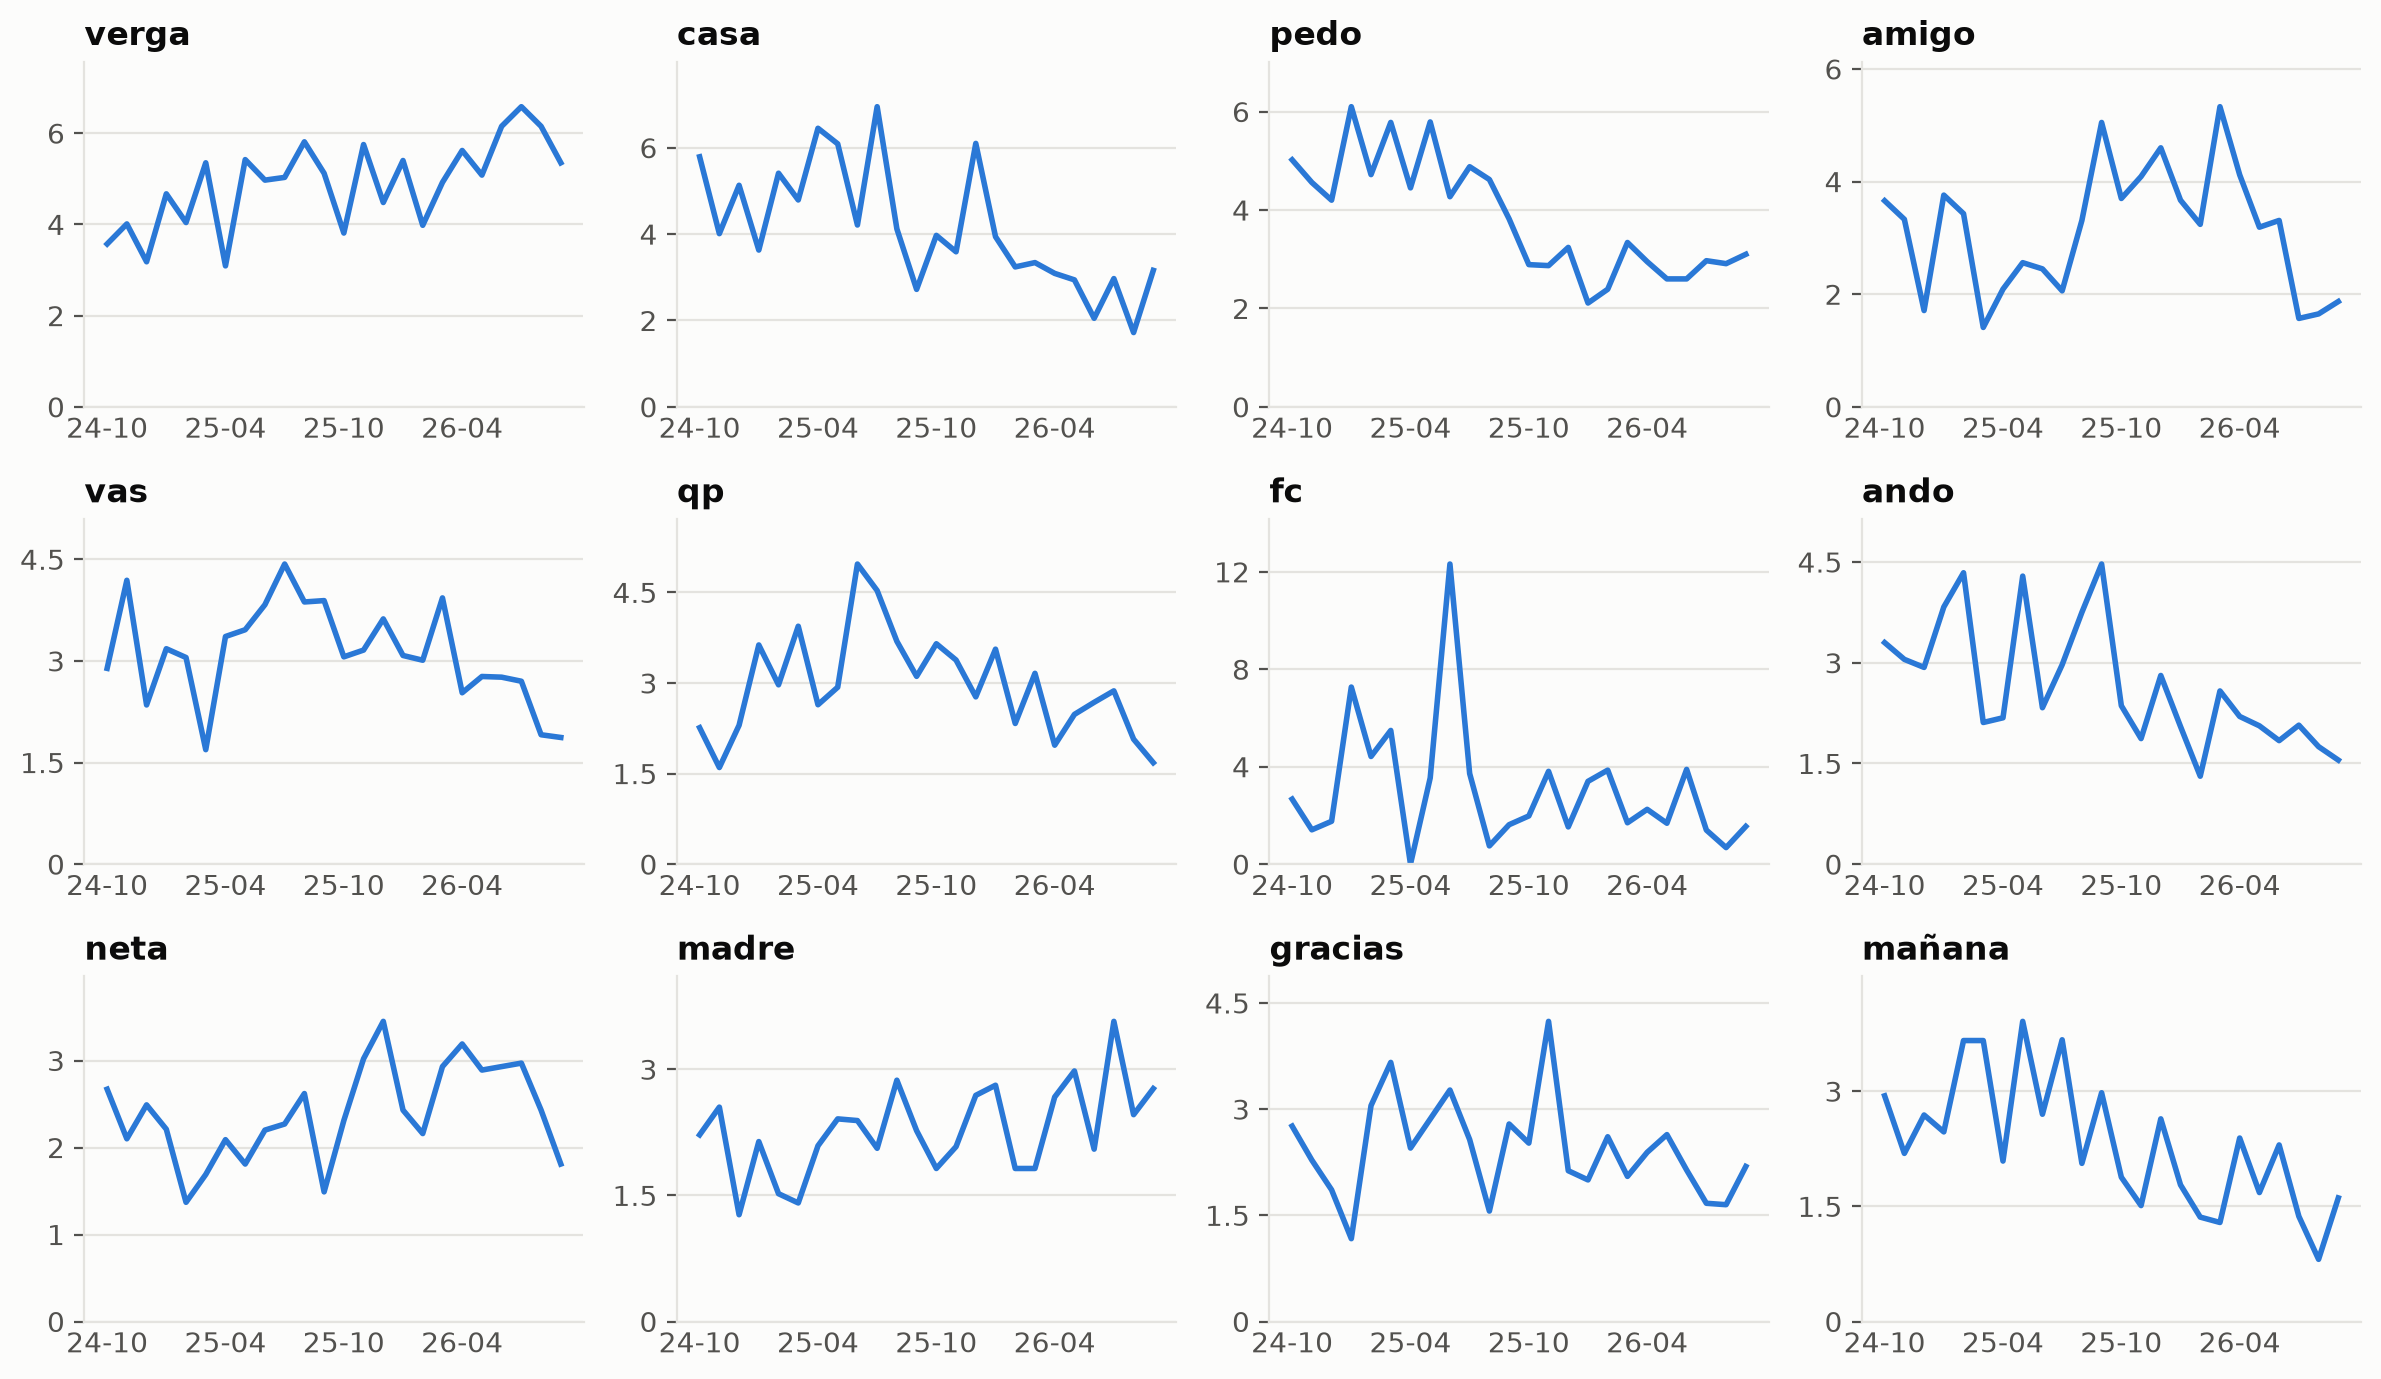

In [ ]:
monthly_words = mo.sql(
    f"""
    WITH content AS (
        SELECT strftime(date_trunc('month', m.timestamp), '%Y-%m') AS mes, t.token
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
    ),
    top_words AS (
        SELECT token, row_number() OVER (ORDER BY count(*) DESC, token) AS lugar
        FROM content
        GROUP BY token
        QUALIFY lugar <= 12
    ),
    months AS (
        SELECT mes, count(*) AS total FROM content GROUP BY mes HAVING count(*) >= 1000
    )
    SELECT
        c.mes,
        w.token AS palabra,
        w.lugar,
        round(1000.0 * count(*) / m.total, 2) AS por_mil
    FROM content AS c
    JOIN months AS m USING (mes)
    JOIN top_words AS w USING (token)
    GROUP BY c.mes, w.token, w.lugar, m.total
    ORDER BY w.lugar, c.mes
    """,
    engine=con,
    output=False,
)
_months = sorted(set(monthly_words["mes"]))
_fig, _axes = plt.subplots(3, 4, figsize=(12, 7))
_top_words = monthly_words.unique("palabra").sort("lugar")["palabra"]
for _ax, _word in zip(_axes.flat, _top_words):
    _rows = monthly_words.filter(pl.col("palabra") == _word)
    _rate = dict(zip(_rows["mes"], _rows["por_mil"]))
    line(
        [month[2:] for month in _months],
        [_rate.get(month, 0) for month in _months],
        _word,
        every=6,
        markers=False,
        ax=_ax,
    )
_fig

In [ ]:
word_shift = mo.sql(
    f"""
    WITH content AS (
        SELECT m.timestamp > (SELECT max(timestamp) - INTERVAL 1 YEAR FROM messages) AS reciente, t.token
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
    ),
    totals AS (
        SELECT count(*) FILTER (reciente) AS reciente, count(*) FILTER (NOT reciente) AS anterior
        FROM content
    ),
    counts AS (
        SELECT
            token AS palabra,
            count(*) FILTER (reciente) AS ultimo_ano,
            count(*) FILTER (NOT reciente) AS año_anterior
        FROM content
        GROUP BY token
        HAVING count(*) >= 150
    )
    SELECT
        palabra,
        ultimo_ano,
        año_anterior,
        round((ultimo_ano / t.reciente) / nullif(año_anterior / t.anterior, 0), 2) AS veces_mas_usada
    FROM counts, totals AS t
    ORDER BY veces_mas_usada DESC NULLS FIRST
    """,
    output=False,
    engine=con
)

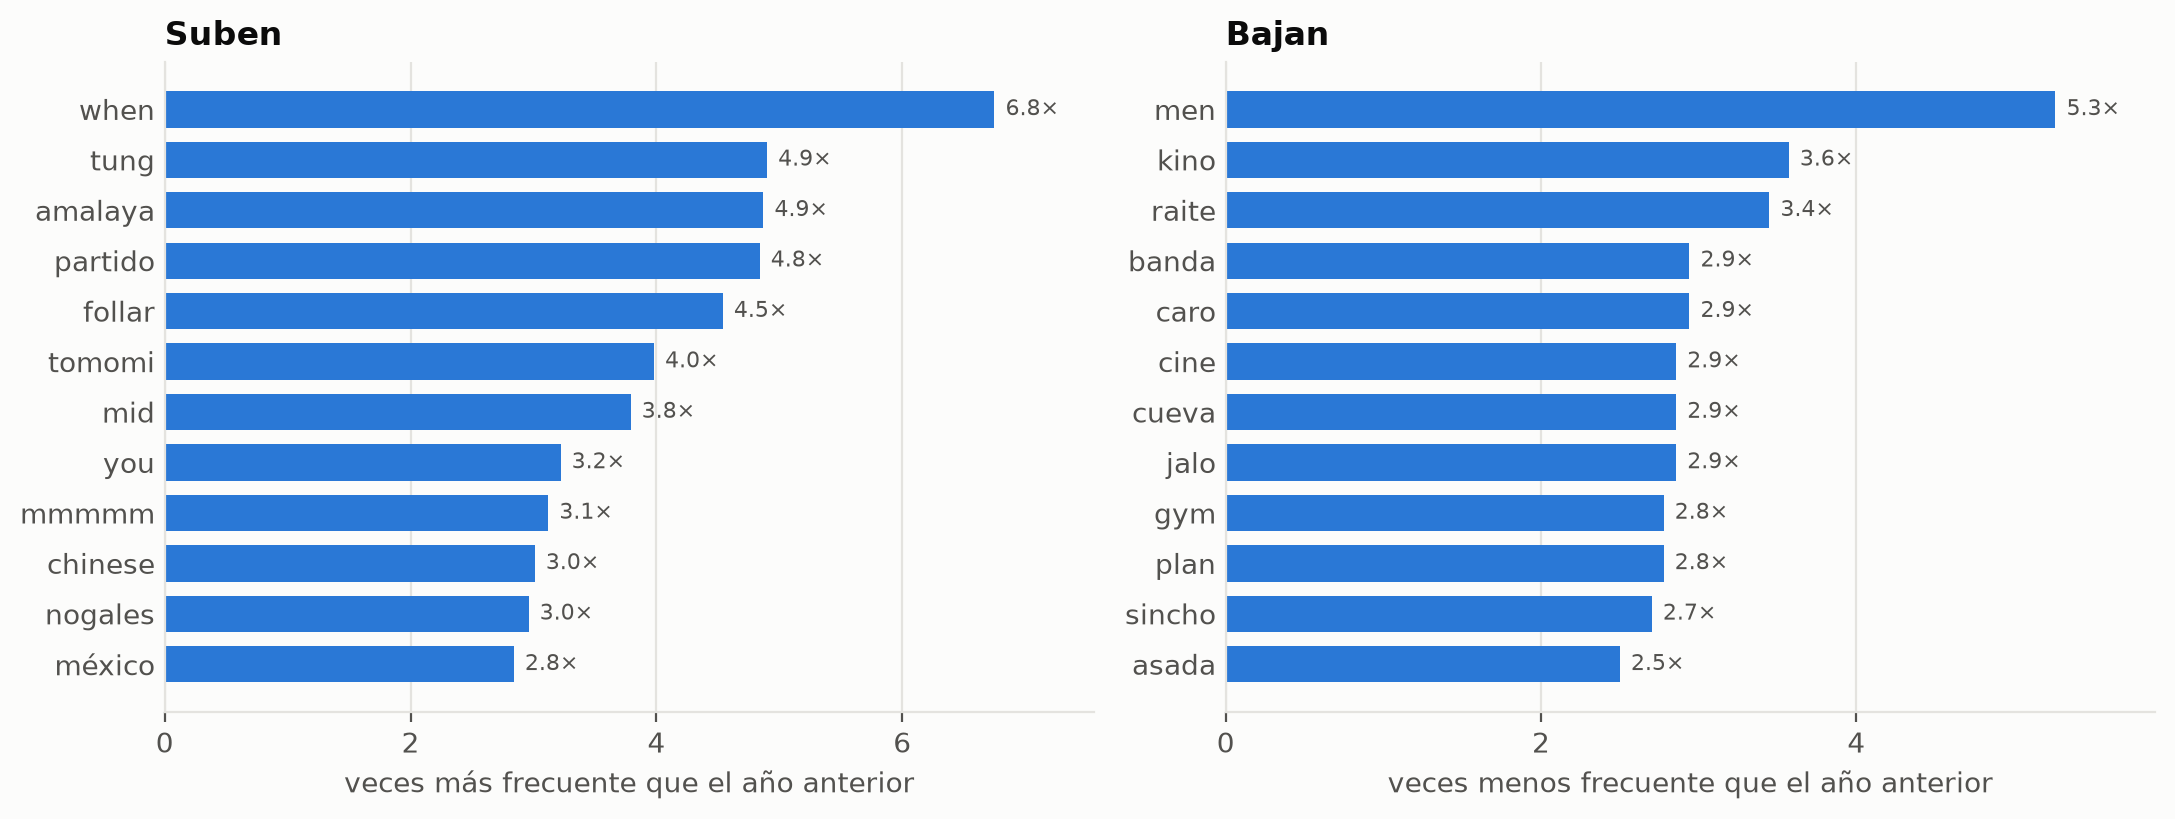

In [ ]:
_steady = word_shift.filter((pl.col("ultimo_ano") >= 20) & (pl.col("año_anterior") >= 20))
_rising = _steady.sort("veces_mas_usada", descending=True).head(12)
_falling = (
    _steady.with_columns(veces_menos=1 / pl.col("veces_mas_usada"))
    .sort("veces_menos", descending=True)
    .head(12)
)
_fig, _axes = plt.subplots(1, 2, figsize=(11, 4.2))
barh(
    _rising["palabra"],
    _rising["veces_mas_usada"],
    "Suben",
    "veces más frecuente que el año anterior",
    fmt="{:.1f}×",
    ax=_axes[0],
)
barh(
    _falling["palabra"],
    _falling["veces_menos"],
    "Bajan",
    "veces menos frecuente que el año anterior",
    fmt="{:.1f}×",
    ax=_axes[1],
)
_fig

In [ ]:
_new = word_shift.filter((pl.col("año_anterior") <= 2) & (pl.col("ultimo_ano") >= 100))
note(
    "Las barras comparan la frecuencia de cada palabra (por palabras con contenido) en "
    "los últimos 12 meses contra los 12 anteriores, entre palabras usadas al menos 20 "
    "veces en cada periodo. Palabras **casi nuevas** (100 veces o más en el último año "
    "y a lo sumo 2 antes): "
    + (", ".join(f"*{word}*" for word in _new["palabra"]) or "ninguna")
    + "."
)

Las barras comparan la frecuencia de cada palabra (por palabras con contenido) en los últimos 12 meses contra los 12 anteriores, entre palabras usadas al menos 20 veces en cada periodo. Palabras casi nuevas (100 veces o más en el último año y a lo sumo 2 antes): claude , beavertale .

## Conclusiones

**Qué aprendí del grupo.** Son 42 personas y casi 260 mil mensajes en dos años, pero
6 personas escriben la mitad. Se escribe sobre todo entre semana (más del doble que
en fin de semana) y de 10 a 12 de la mañana; de madrugada casi no hay nada. Los
mensajes son cortos: la mayoría tiene 4 palabras o menos. Las palabras más usadas son
groserías y planes para verse (*casa*, *mañana*), y cada quien tiene sus muletillas y
chistes internos. Un mes puede tener el triple de mensajes que otro con las mismas
personas.

**Qué aprendí del análisis.** Limpiar bien los datos (tipos de mensaje, alias, stop
words, risas) importó más que cualquier gráfica. spaCy no entiende la jerga y se
equivoca con los adjetivos, así que hay que leer esos resultados con reserva. El
TF-IDF me sirvió para algo que no buscaba: encontrar nombres que el enmascarado dejó
pasar, y hay que revisar `extra_names` cada vez.

**Qué me sorprendió.** Que el grupo manda el doble de stickers que de emojis, y que
quien más mensajes manda no es quien más palabras escribe. También que quien inicia
más conversaciones no es quien las cierra.

**Qué me gustaría analizar más a fondo.** Quién le responde a quién y quién menciona a
quién, y qué tan rápido se contesta. Cómo cambia cada persona con el tiempo (cuánto
escribe, qué palabras usa). Sentimiento y temas, con un modelo que sí entienda el
español de chat. Y los audios, las ubicaciones, quién edita y quién borra mensajes.